<a href="https://colab.research.google.com/github/fatihpossumah/pca_mental-health_dataset/blob/main/Implementasi_PCA_Mental_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementasi PCA pada Data Kesehatan Mental

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMRegressor

import copy
import time
print('Selesai import Library!')

Selesai import Library!


In [2]:
df = pd.read_csv('mental_health.csv')

In [3]:
df.drop_duplicates(inplace=True)

In [4]:
print(f'Shape dataset: {df.shape}')

Shape dataset: (10000, 51)


In [5]:
df.head(10)

,Age,Gender,Country,Education,Marital_Status,Income_Level,Employment_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,...,Ever_Sought_Treatment,On_Therapy_Now,On_Medication,Trauma_History,Social_Support,Close_Friends_Count,Feel_Understood,Loneliness,Discuss_Mental_Health,Has_Mental_Health_Issue
0,40,Male,USA,Some College,Single,Middle,Full-time,27,No,6,...,1,0,0,0,9,3,4,6,Sometimes,1
1,33,Male,India,Bachelor,Married,Middle,Unemployed,47,No,6,...,0,0,0,0,3,2,7,7,Sometimes,1
2,42,Male,Other,High School,Single,Low,Full-time,53,No,1,...,1,0,0,1,5,3,6,9,Sometimes,1
3,53,Male,Germany,Bachelor,Single,Middle,Unemployed,42,No,10,...,0,1,0,0,1,3,10,5,Never,1
4,32,Female,India,Bachelor,Single,High,Student,13,No,4,...,0,0,0,0,1,5,1,6,Sometimes,1
5,32,Male,UK,Some College,Married,Middle,Part-time,53,No,3,...,0,0,0,0,3,5,6,9,Never,1
6,53,Male,India,Some College,Single,Middle,Full-time,41,No,4,...,0,1,0,0,2,1,4,2,Sometimes,1
7,44,Female,UK,Master,Married,Middle,Student,13,Hybrid,2,...,1,0,0,0,8,2,2,8,Yes easily,1
8,29,Male,India,High School,Single,Middle,Part-time,22,No,10,...,0,1,1,1,4,6,1,6,Sometimes,1
9,41,Female,India,Some College,Single,High,Student,29,Yes,9,...,1,0,0,0,5,5,5,2,Sometimes,0


## A. Insight Visualisasi (EDA)

### A.1 Distribusi Target

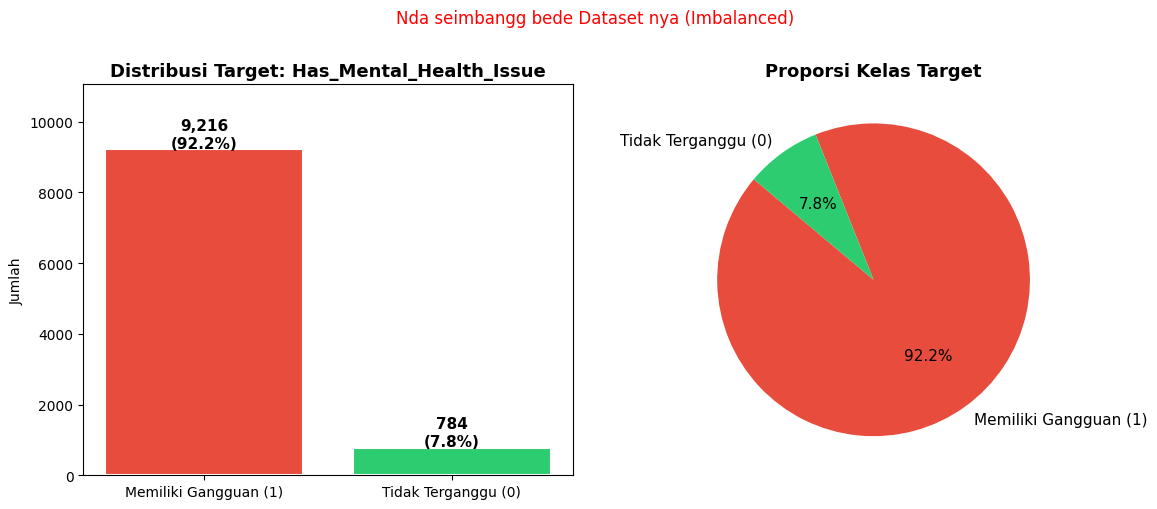

<Figure size 640x480 with 0 Axes>


 Catatan: Kelas '1' mendominasi 92.2% data.
   Karena ini IMBALANCED dataset — perhatikan ki nanti klo evaluasi model.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['Has_Mental_Health_Issue'].value_counts()
labels = ['Memiliki Gangguan (1)', 'Tidak Terganggu (0)']

# Bar chart
colors = ['#e74c3c', '#2ecc71']
bars = axes[0].bar(labels, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Target: Has_Mental_Health_Issue', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(target_counts.values) * 1.2)

# Pie chart
axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Nda seimbangg bede Dataset nya (Imbalanced)', fontsize=12, color='red', y=1.01)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

print(f"\n Catatan: Kelas '1' mendominasi {target_counts[1]/len(df)*100:.1f}% data.")
print("   Karena ini IMBALANCED dataset — perhatikan ki nanti klo evaluasi model.")

### A.2 Distribusi Fitur Numerik

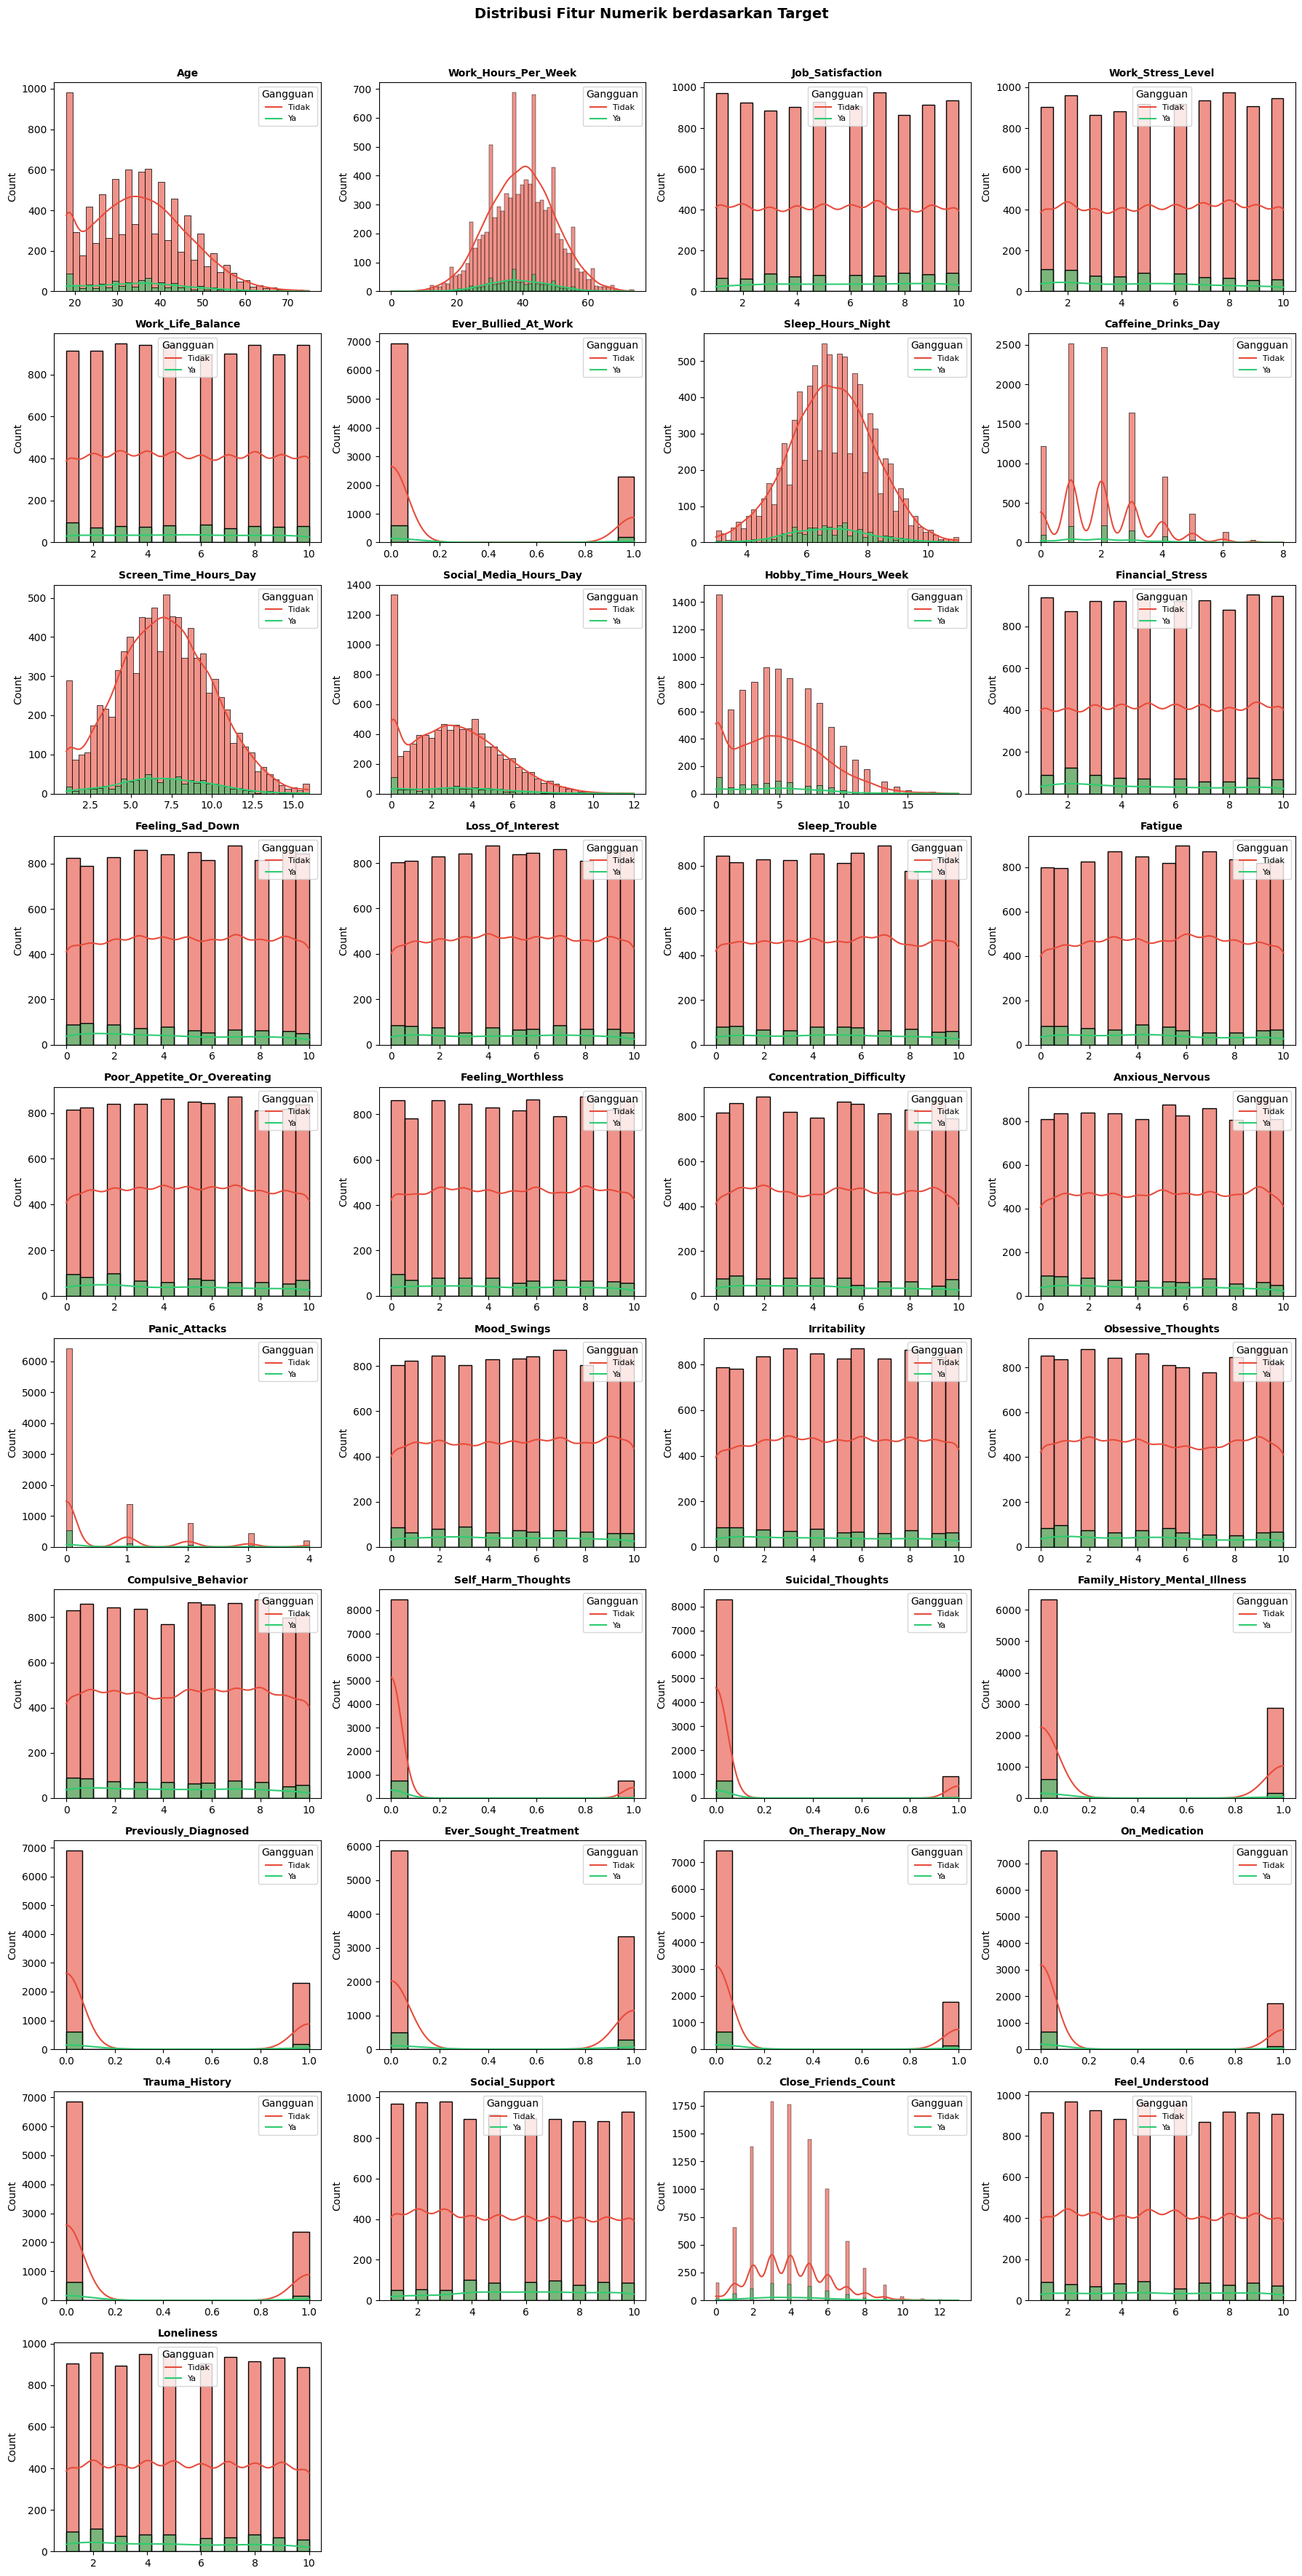

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Has_Mental_Health_Issue')

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Has_Mental_Health_Issue',
                 palette={0: '#2ecc71', 1: '#e74c3c'}, kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['Tidak', 'Ya'], title='Gangguan', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### A.3 Distribusi Fitur Kategorikal vs Target

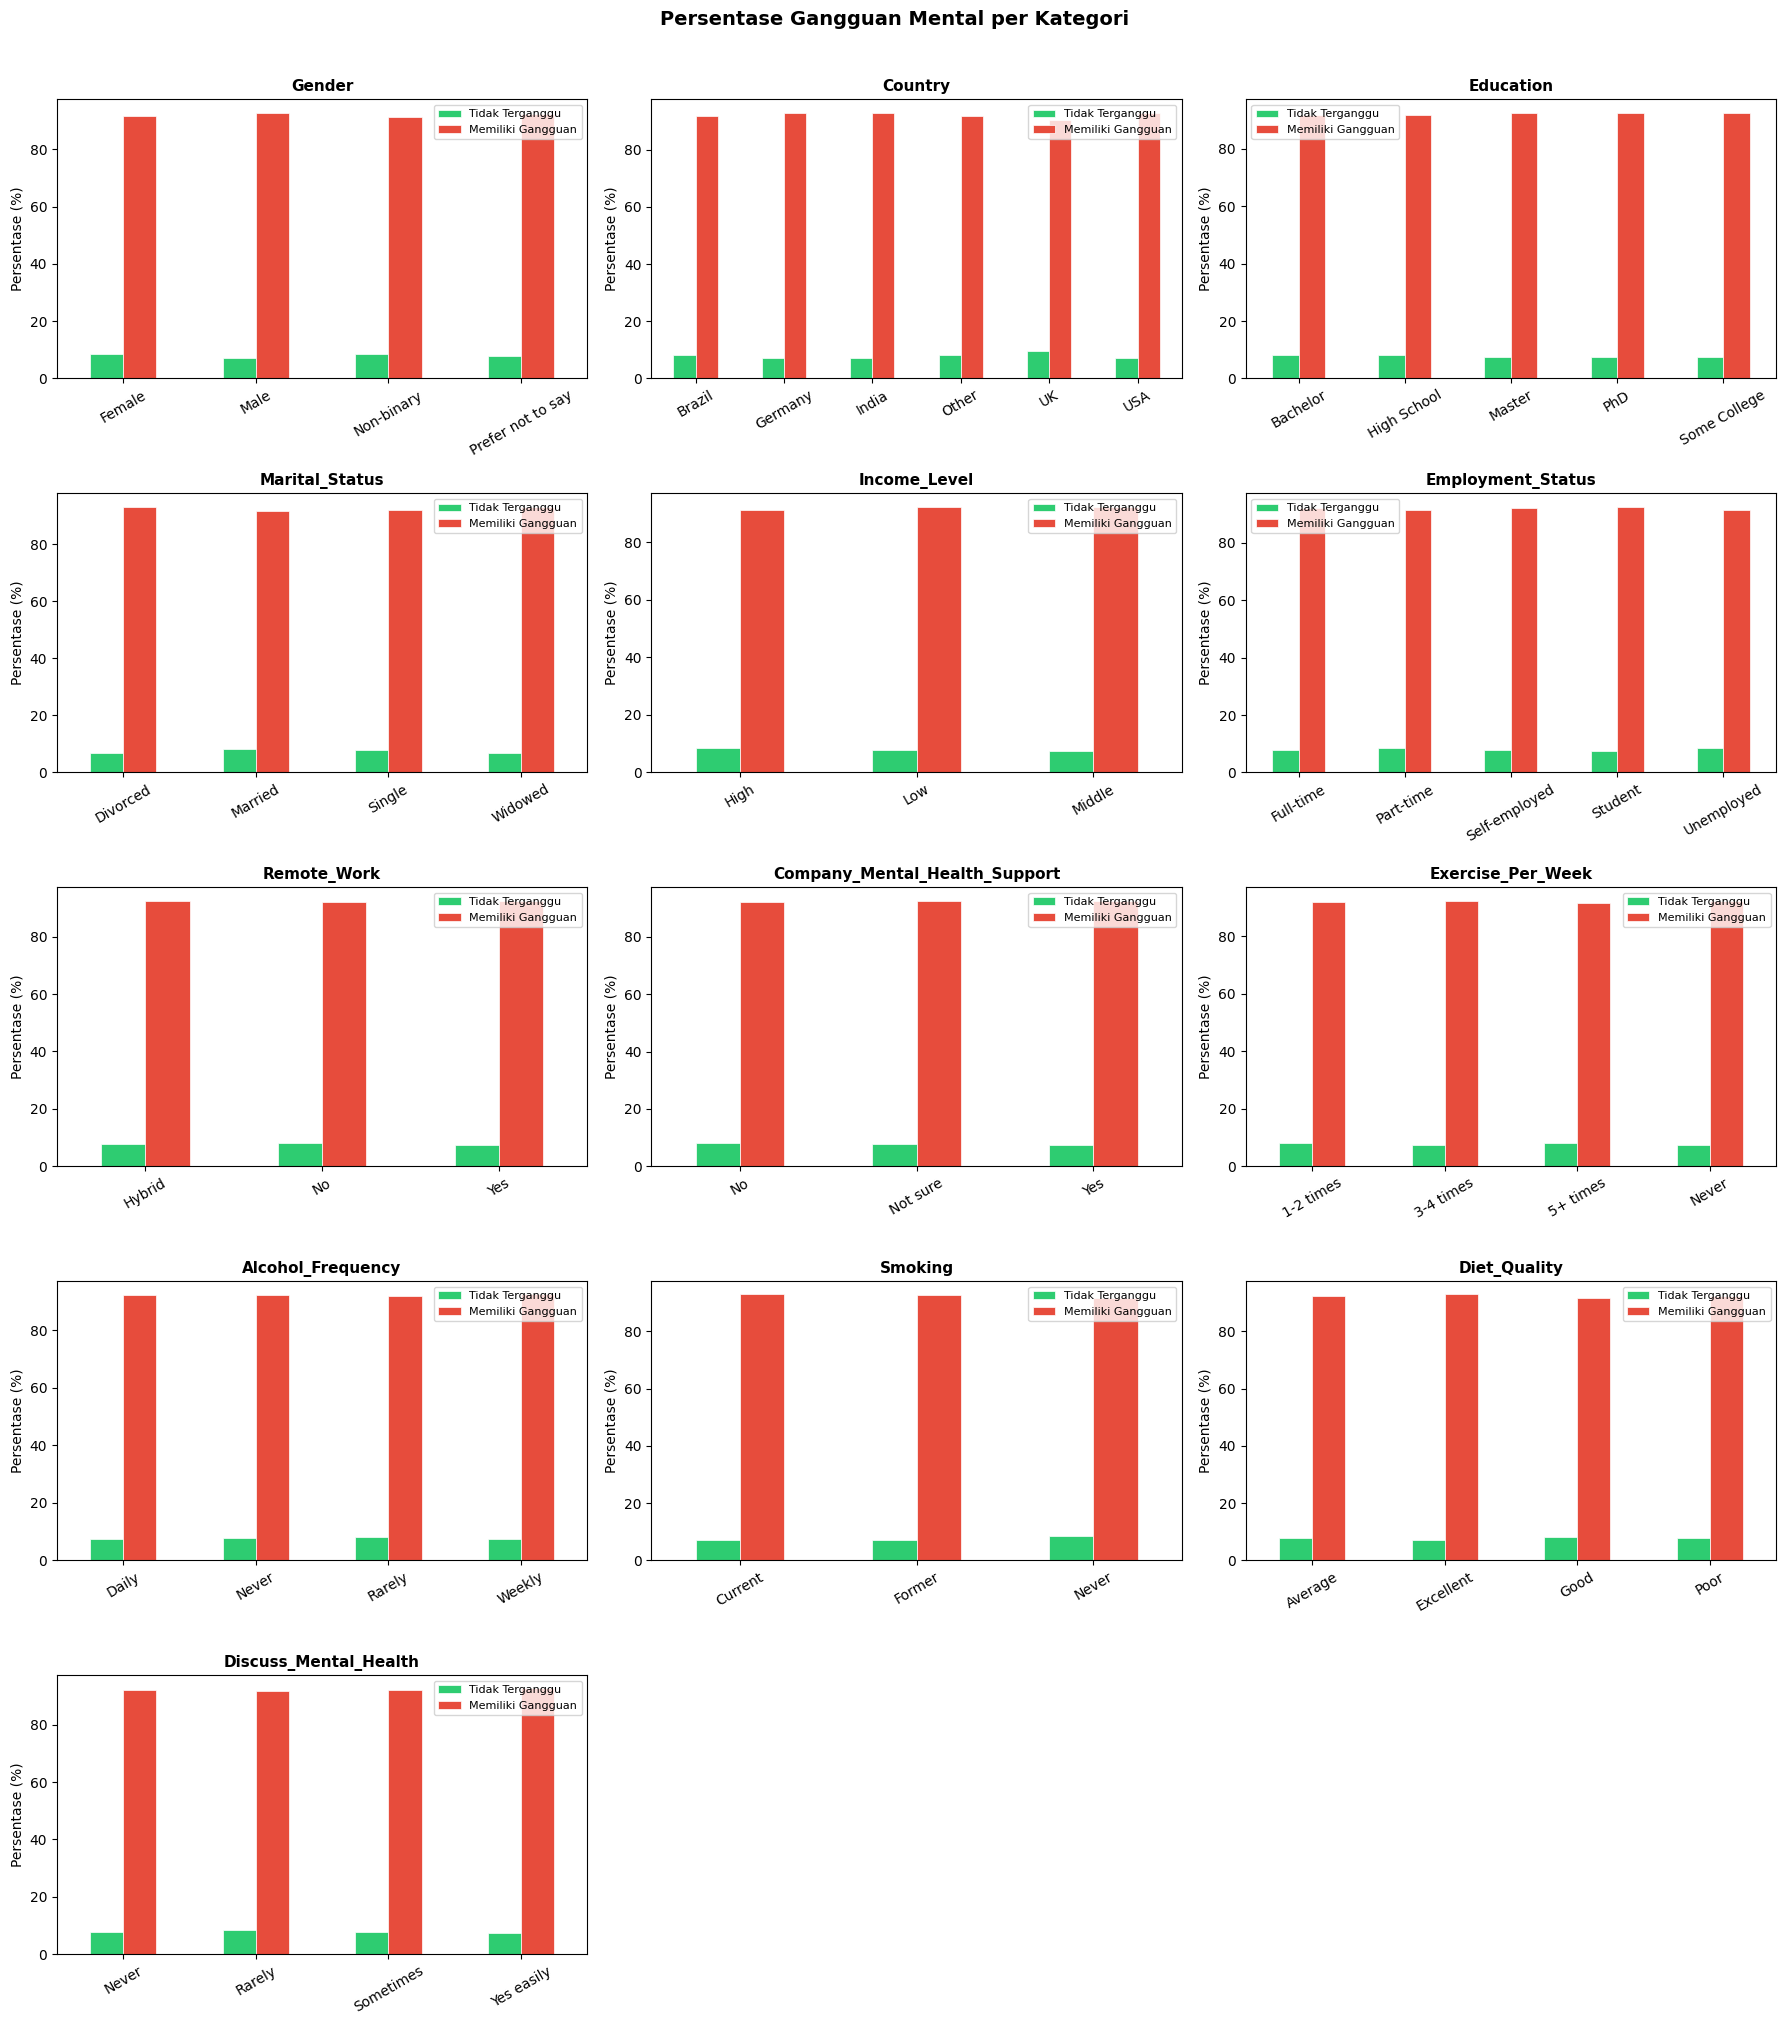

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    cross = pd.crosstab(df[col], df['Has_Mental_Health_Issue'], normalize='index') * 100
    cross.columns = ['Tidak Terganggu', 'Memiliki Gangguan']
    cross.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
               edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Persentase Gangguan Mental per Kategori', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### A.4 Boxplot Outlier

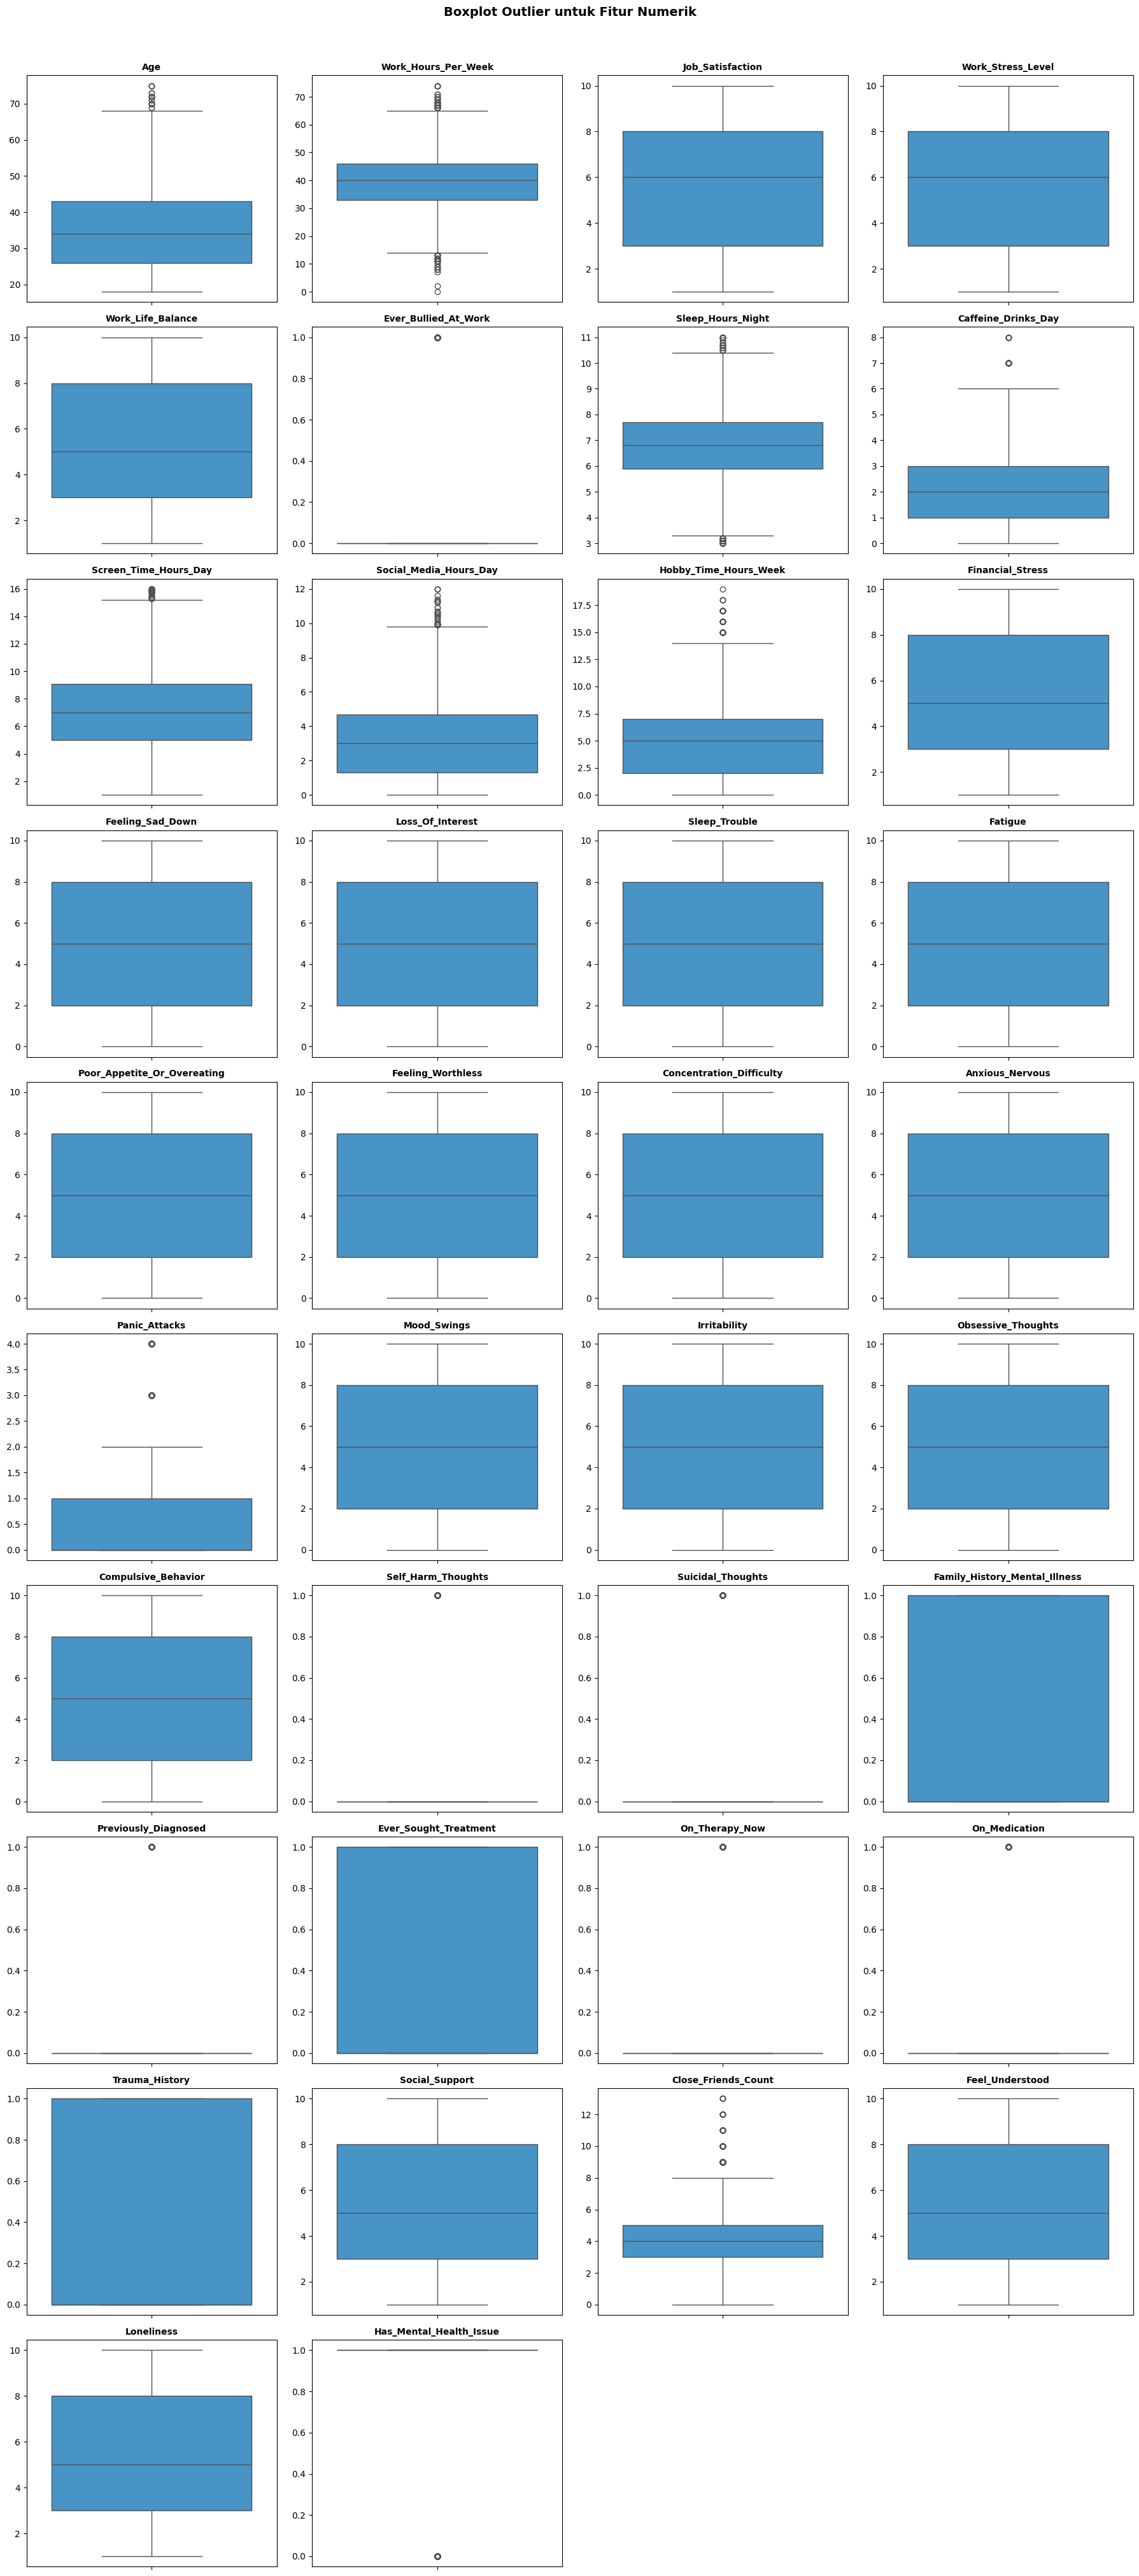

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

n_cols = 4
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Outlier untuk Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
print('Mulai penanganan outlier dengan Metode IQR Winsorizing (Robust & Best Practice)...')
print('   → Lebih robust dari Z-Score karena tidak terpengaruh distribusi non-normal\n')

numerical_cols_for_outliers = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Has_Mental_Health_Issue' in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove('Has_Mental_Health_Issue')

outlier_summary = []
total_before = 0
total_after  = 0

for col in numerical_cols_for_outliers:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    n_outlier = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()
    total_before += n_outlier

    # Winsorizing: cap ke batas IQR
    df[col] = df[col].clip(lower=lower_fence, upper=upper_fence)

    n_after = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()
    total_after += n_after

    outlier_summary.append({
        'Kolom': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Lower Fence': round(lower_fence, 2),
        'Upper Fence': round(upper_fence, 2),
        'Outlier Sebelum': n_outlier, 'Outlier Sesudah': n_after
    })

df_outlier_summary = pd.DataFrame(outlier_summary)
print('Detail penanganan outlier per kolom:')
display(df_outlier_summary)
print(f'\nTotal outlier SEBELUM : {total_before}')
print(f'Total outlier SESUDAH  : {total_after}')
print(f'Dataset shape tetap   : {df.shape} (tidak ada baris dihapus)')
print('\n✔ IQR Winsorizing selesai.')

Mulai penanganan outlier dengan Metode IQR Winsorizing (Robust & Best Practice)...
   → Lebih robust dari Z-Score karena tidak terpengaruh distribusi non-normal

Detail penanganan outlier per kolom:


,Kolom,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Sebelum,Outlier Sesudah
0,Age,26.0,43.0,17.0,0.50,68.50,25,0
1,Work_Hours_Per_Week,33.0,46.0,13.0,13.50,65.50,94,0
2,Job_Satisfaction,3.0,8.0,5.0,-4.50,15.50,0,0
3,Work_Stress_Level,3.0,8.0,5.0,-4.50,15.50,0,0
4,Work_Life_Balance,3.0,8.0,5.0,-4.50,15.50,0,0
5,Ever_Bullied_At_Work,0.0,0.0,0.0,0.00,0.00,2474,0
6,Sleep_Hours_Night,5.9,7.7,1.8,3.20,10.40,84,0
7,Caffeine_Drinks_Day,1.0,3.0,2.0,-2.00,6.00,46,0
8,Screen_Time_Hours_Day,5.0,9.1,4.1,-1.15,15.25,36,0
9,Social_Media_Hours_Day,1.3,4.7,3.4,-3.80,9.80,33,0



Total outlier SEBELUM : 11737
Total outlier SESUDAH  : 0
Dataset shape tetap   : (10000, 51) (tidak ada baris dihapus)

✔ IQR Winsorizing selesai.


### A.4b Feature Engineering

In [11]:
print('Mulai Feature Engineering (adaptive)...')

# Deteksi kolom yang ada
available_cols = set(df.columns)
new_features_created = []

# 1. Interaction Features (dengan conditional checks)
# Stress × Sleep
if 'Stress_Level' in available_cols and 'Sleep_Hours' in available_cols:
    df['Stress_x_Sleep'] = df['Stress_Level'] * (10 - df['Sleep_Hours'])
    new_features_created.append('Stress_x_Sleep')

# 2. Work Productivity Gap
if 'Work_Hours_Per_Week' in available_cols and 'Productivity_Score' in available_cols:
    df['Work_Productivity_Gap'] = df['Work_Hours_Per_Week'] - df['Productivity_Score']
    new_features_created.append('Work_Productivity_Gap')

# 3. Social Support Gap
if 'Social_Support_Score' in available_cols and 'Social_Interaction_Score' in available_cols:
    df['Social_Support_Gap'] = df['Social_Support_Score'] - df['Social_Interaction_Score']
    new_features_created.append('Social_Support_Gap')

# 4. Wellness Score
if 'Sleep_Hours' in available_cols and 'Physical_Activity_Hours' in available_cols:
    df['Wellness_Score'] = df['Sleep_Hours'] + df['Physical_Activity_Hours']
    new_features_created.append('Wellness_Score')

# 5. Ratio Features
if 'Screen_Time_Hours' in available_cols and 'Sleep_Hours' in available_cols:
    df['Screen_Sleep_Ratio'] = df['Screen_Time_Hours'] / (df['Sleep_Hours'] + 1)
    new_features_created.append('Screen_Sleep_Ratio')

if 'Work_Hours_Per_Week' in available_cols and 'Sleep_Hours' in available_cols:
    df['Work_Life_Balance'] = df['Work_Hours_Per_Week'] / (df['Sleep_Hours'] * 7 + 1)
    new_features_created.append('Work_Life_Balance')

# 6. Polynomial Feature
if 'Stress_Level' in available_cols:
    df['Stress_Level_Sq'] = df['Stress_Level'] ** 2
    new_features_created.append('Stress_Level_Sq')

# 7. Mental Health Risk Score (composite index)
# Cari kolom yang relevan untuk risk score
risk_cols = [c for c in available_cols
             if any(x in c.lower() for x in ['stress', 'sleep', 'screen', 'anxiety', 'depression'])]

if risk_cols:
    # Normalisasi ke 0-1 untuk setiap komponen
    df['Mental_Risk_Score'] = 0
    for col in risk_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        if col_max > col_min:
            df['Mental_Risk_Score'] += (df[col] - col_min) / (col_max - col_min) * 0.1
    new_features_created.append('Mental_Risk_Score')

print(f'\n✔ Fitur baru berhasil dibuat: {len(new_features_created)} fitur')
if new_features_created:
    print(f'  {new_features_created}')
    print(f'\nShape dataset setelah Feature Engineering: {df.shape}')
    print('\nPreview fitur baru:')
    display(df[new_features_created].describe().round(3))
else:
    print('  ⚠ Tidak ada fitur baru yang dibuat (kolom tidak tersedia)')
    print(f'  Kolom yang ada: {sorted(available_cols)}')

print('\n✔ Feature Engineering selesai.')

Mulai Feature Engineering (adaptive)...

✔ Fitur baru berhasil dibuat: 1 fitur
  ['Mental_Risk_Score']

Shape dataset setelah Feature Engineering: (10000, 52)

Preview fitur baru:


,Mental_Risk_Score
count,10000.000
mean,0.242
std,0.062
min,0.025
25%,0.199
50%,0.243
75%,0.285
max,0.444



✔ Feature Engineering selesai.


### A.5 Heatmap Korelasi Fitur Numerik

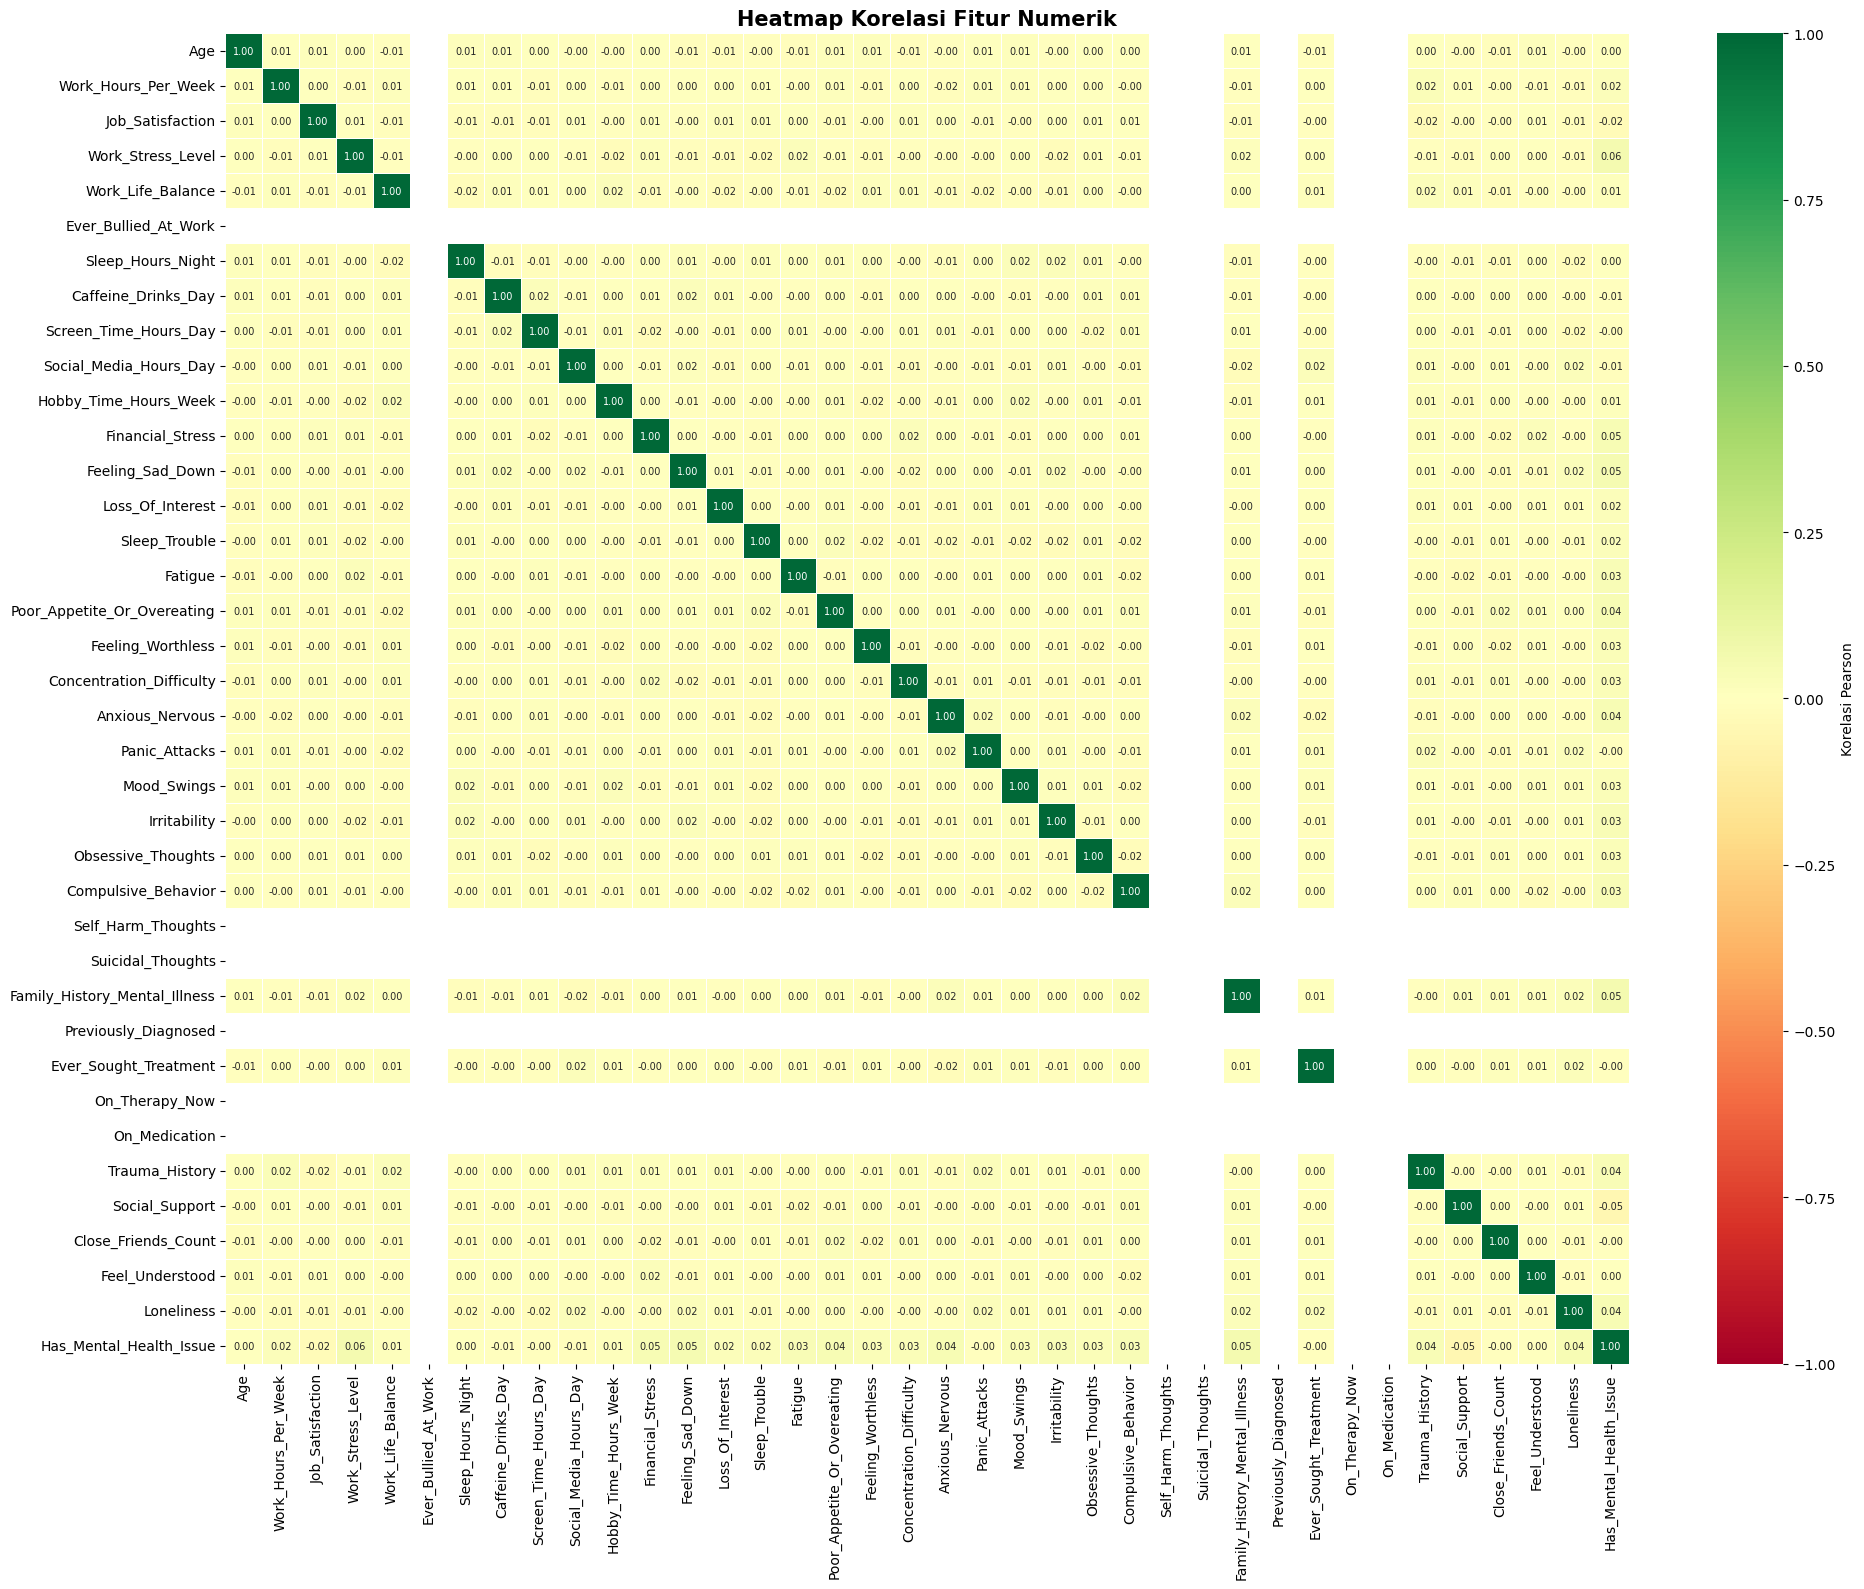

In [12]:
fig, ax = plt.subplots(figsize=(20, 16))

cols_for_corr = [col for col in numerical_cols if col != 'Has_Mental_Health_Issue']
corr_matrix = df[cols_for_corr + ['Has_Mental_Health_Issue']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1, cbar_kws={'label': 'Korelasi Pearson'})

ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### A.6 Top Fitur Berkorelasi dengan Target

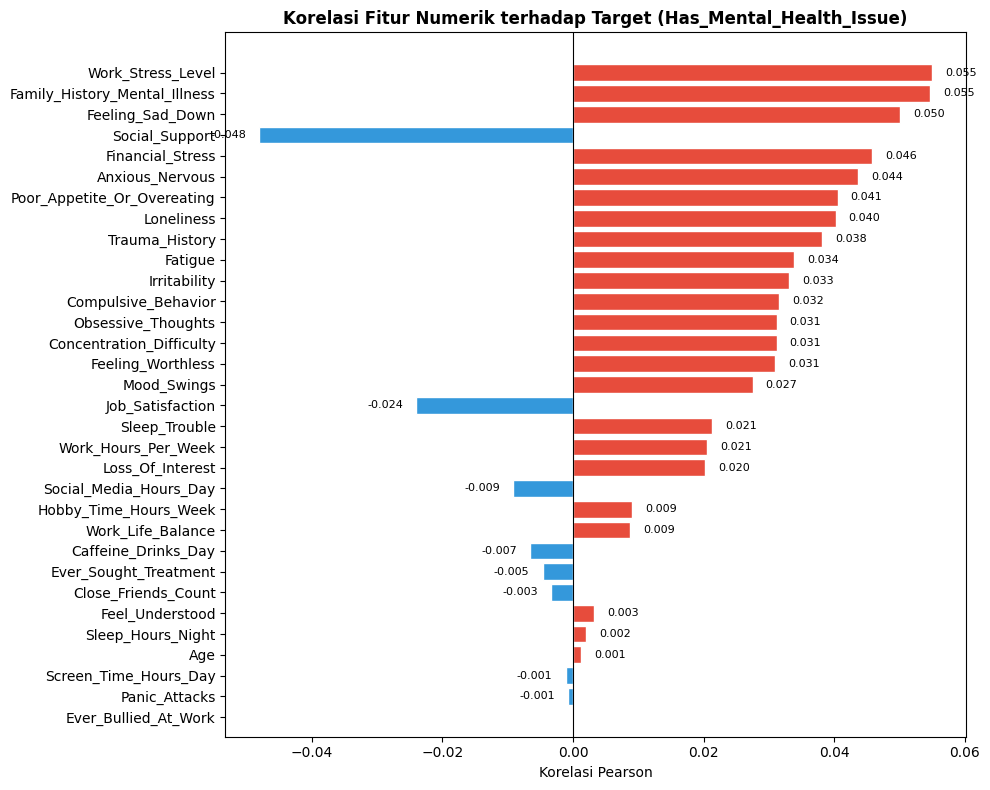


Fitur paling berkorelasi dengan target (top 5):
Work_Stress_Level                0.055028
Family_History_Mental_Illness    0.054693
Feeling_Sad_Down                 0.050075
Social_Support                  -0.048083
Financial_Stress                 0.045807
Name: Has_Mental_Health_Issue, dtype: float64


In [13]:
target_corr = corr_matrix['Has_Mental_Health_Issue'].drop('Has_Mental_Health_Issue').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur Numerik terhadap Target (Has_Mental_Health_Issue)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Korelasi Pearson')

for bar, val in zip(bars, target_corr.values[::-1]):
    ax.text(val + 0.002 if val >= 0 else val - 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()
print('\nFitur paling berkorelasi dengan target (top 5):')
print(target_corr.head())

## B. Encoding Variabel Kategorikal

Strategi encoding:
- **Binary / Nominal tanpa urutan**: Label Encoding (Gender, Remote_Work, dll)
- **Ordinal (ada urutan logis)**: Ordinal Encoding manual (Income, Education, Exercise, dll)

In [14]:
df_encoded = df.copy()

### B.1 Ordinal Encoding

In [15]:
# Income Level: Low < Middle < High
income_order = {'Low': 0, 'Middle': 1, 'High': 2}
df_encoded['Income_Level'] = df_encoded['Income_Level'].map(income_order)
print('Income_Level:', income_order)

Income_Level: {'Low': 0, 'Middle': 1, 'High': 2}


In [16]:
# Education: High School < Some College < Bachelor < Master < PhD
education_order = {'High School': 0, 'Some College': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df_encoded['Education'] = df_encoded['Education'].map(education_order)
print('Education:', education_order)

Education: {'High School': 0, 'Some College': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}


In [17]:
# Exercise_Per_Week: Never < 1-2 times < 3-4 times < 5+ times
exercise_order = {'Never': 0, '1-2 times': 1, '3-4 times': 2, '5+ times': 3}
df_encoded['Exercise_Per_Week'] = df_encoded['Exercise_Per_Week'].map(exercise_order)
print('Exercise_Per_Week:', exercise_order)

Exercise_Per_Week: {'Never': 0, '1-2 times': 1, '3-4 times': 2, '5+ times': 3}


In [18]:
# Alcohol_Frequency: Never < Rarely < Weekly < Daily
alcohol_order = {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Daily': 3}
df_encoded['Alcohol_Frequency'] = df_encoded['Alcohol_Frequency'].map(alcohol_order)
print('Alcohol_Frequency:', alcohol_order)

Alcohol_Frequency: {'Never': 0, 'Rarely': 1, 'Weekly': 2, 'Daily': 3}


In [19]:
# Diet_Quality: Poor < Average < Good < Excellent
diet_order = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
df_encoded['Diet_Quality'] = df_encoded['Diet_Quality'].map(diet_order)
print('Diet_Quality:', diet_order)

Diet_Quality: {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}


In [20]:
# Discuss_Mental_Health: Never < Rarely < Sometimes < Yes easily
discuss_order = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Yes easily': 3}
df_encoded['Discuss_Mental_Health'] = df_encoded['Discuss_Mental_Health'].map(discuss_order)
print('Discuss_Mental_Health:', discuss_order)

Discuss_Mental_Health: {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Yes easily': 3}


In [21]:
# Company_Mental_Health_Support: No < Not sure < Yes
support_order = {'No': 0, 'Not sure': 1, 'Yes': 2}
df_encoded['Company_Mental_Health_Support'] = df_encoded['Company_Mental_Health_Support'].map(support_order)
print('Company_Mental_Health_Support:', support_order)

Company_Mental_Health_Support: {'No': 0, 'Not sure': 1, 'Yes': 2}


### B.1 One Hot Encoding

In [22]:
ohe_cols = ['Gender', 'Country', 'Marital_Status', 'Employment_Status',
            'Remote_Work', 'Smoking']

In [23]:
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

In [24]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [25]:
print('\nOne-Hot Encoding selesai untuk kolom:', ohe_cols)
for col in ohe_cols:
    new_cols = [c for c in df_encoded.columns if c.startswith(col + '_')]
    print(f'  {col} → {new_cols}')


One-Hot Encoding selesai untuk kolom: ['Gender', 'Country', 'Marital_Status', 'Employment_Status', 'Remote_Work', 'Smoking']
  Gender → ['Gender_Male', 'Gender_Non-binary', 'Gender_Prefer not to say']
  Country → ['Country_Germany', 'Country_India', 'Country_Other', 'Country_UK', 'Country_USA']
  Marital_Status → ['Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Widowed']
  Employment_Status → ['Employment_Status_Part-time', 'Employment_Status_Self-employed', 'Employment_Status_Student', 'Employment_Status_Unemployed']
  Remote_Work → ['Remote_Work_No', 'Remote_Work_Yes']
  Smoking → ['Smoking_Former', 'Smoking_Never']


In [26]:
print('\nSemua kolom kategorikal berhasil di-encode')
print(f'Shape setelah encoding: {df_encoded.shape}')
df_encoded.head(10)


Semua kolom kategorikal berhasil di-encode
Shape setelah encoding: (10000, 65)


,Age,Education,Income_Level,Work_Hours_Per_Week,Job_Satisfaction,Work_Stress_Level,Work_Life_Balance,Ever_Bullied_At_Work,Company_Mental_Health_Support,Exercise_Per_Week,...,Marital_Status_Single,Marital_Status_Widowed,Employment_Status_Part-time,Employment_Status_Self-employed,Employment_Status_Student,Employment_Status_Unemployed,Remote_Work_No,Remote_Work_Yes,Smoking_Former,Smoking_Never
0,40.0,1,1,27.0,6,7,7,0,0,1,...,1,0,0,0,0,0,1,0,1,0
1,33.0,2,1,47.0,6,1,5,0,1,1,...,0,0,0,0,0,1,1,0,0,0
2,42.0,0,0,53.0,1,3,8,0,1,2,...,1,0,0,0,0,0,1,0,1,0
3,53.0,2,1,42.0,10,3,5,0,0,0,...,1,0,0,0,0,1,1,0,1,0
4,32.0,2,2,13.5,4,7,7,0,1,1,...,1,0,0,0,1,0,1,0,0,0
5,32.0,1,1,53.0,3,5,5,0,2,1,...,0,0,1,0,0,0,1,0,0,1
6,53.0,1,1,41.0,4,1,6,0,0,2,...,1,0,0,0,0,0,1,0,1,0
7,44.0,3,1,13.5,2,10,8,0,0,2,...,0,0,0,0,1,0,0,0,1,0
8,29.0,0,1,22.0,10,4,3,0,2,3,...,1,0,1,0,0,0,1,0,1,0
9,41.0,1,2,29.0,9,6,10,0,1,0,...,1,0,0,0,1,0,0,1,1,0


In [27]:
missing_after = df_encoded.isnull().sum()
print('Missing values setelah encoding:')
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else 'Tidak ada missing values')
print(f'\nSemua kolom sekarang numerik: {df_encoded.dtypes.unique()}')

Missing values setelah encoding:
Tidak ada missing values

Semua kolom sekarang numerik: [dtype('float64') dtype('int64')]


## C. Penerapan PCA

### C.1 Persiapan Fitur & Standarisasi


In [28]:
# Prepare features and target
# Hapus target dan kolom yang tidak perlu
cols_to_drop = ['Has_Mental_Health_Issue']
if 'Loneliness' in df_encoded.columns:
    cols_to_drop.append('Loneliness')  # untuk regresi, jangan pakai di klasifikasi

X = df_encoded.drop(columns=[c for c in cols_to_drop if c in df_encoded.columns])
y = df_encoded['Has_Mental_Health_Issue']

In [29]:
print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Jumlah fitur: {X.shape[1]}')

Shape X: (10000, 63)
Shape y: (10000,)
Jumlah fitur: 63


In [30]:
from sklearn.preprocessing import RobustScaler

# Gunakan RobustScaler: lebih robust terhadap outlier (menggunakan median & IQR)
# Cocok digunakan setelah IQR Winsorizing untuk konsistensi
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print('Standarisasi dengan RobustScaler selesai (berbasis median & IQR, robust terhadap outlier)')

Standarisasi dengan RobustScaler selesai (berbasis median & IQR, robust terhadap outlier)


### C.2 PCA — Menentukan Jumlah Komponen Optimal

In [31]:
pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

In [32]:
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

In [33]:
# ---- Metode 1: Cumulative Explained Variance >= 90% ----
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

# ---- Metode 2: Kaiser Rule (eigenvalue > 1) ----
eigenvalues = pca_full.explained_variance_
n_kaiser = np.sum(eigenvalues > 1)

# ---- Metode 3: Elbow Method (selisih antar eigenvalue) ----
diffs = np.diff(explained_var)
n_elbow = np.argmin(diffs) + 1  # titik penurunan paling tajam

print('=== Perbandingan Metode Pemilihan n_components ===')
print(f'  Metode Cumulative Variance ≥ 90% : {n_components_90} komponen')
print(f'  Metode Cumulative Variance ≥ 95% : {n_components_95} komponen')
print(f'  Metode Kaiser Rule (eigenvalue>1) : {n_kaiser} komponen')
print(f'  Metode Elbow (knee point)         : {n_elbow} komponen')

# Pilih: ambil maksimum antara 90% variance dan Kaiser Rule
# → Kaiser menjamin setiap komponen membawa informasi > rata-rata
n_components_optimal = max(n_components_90, n_kaiser)
print(f'\n✔ n_components OPTIMAL yang dipilih: {n_components_optimal}')
print(f'  (max dari Variance 90%={n_components_90} dan Kaiser={n_kaiser})')

=== Perbandingan Metode Pemilihan n_components ===
  Metode Cumulative Variance ≥ 90% : 39 komponen
  Metode Cumulative Variance ≥ 95% : 44 komponen
  Metode Kaiser Rule (eigenvalue>1) : 2 komponen
  Metode Elbow (knee point)         : 1 komponen

✔ n_components OPTIMAL yang dipilih: 39
  (max dari Variance 90%=39 dan Kaiser=2)


In [34]:
print(f'Jumlah komponen untuk menjelaskan ≥ 90% variansi : {n_components_90}')
print(f'Jumlah komponen untuk menjelaskan ≥ 95% variansi : {n_components_95}')
print(f'Jumlah komponen Kaiser Rule (eigenvalue > 1)      : {n_kaiser}')
print(f'Jumlah komponen Optimal yang digunakan            : {n_components_optimal}')
print(f'Total fitur asli                                  : {X.shape[1]}')
print(f'Reduksi dimensi: {X.shape[1]} → {n_components_optimal} fitur ({(1-n_components_optimal/X.shape[1])*100:.1f}% reduksi)')

Jumlah komponen untuk menjelaskan ≥ 90% variansi : 39
Jumlah komponen untuk menjelaskan ≥ 95% variansi : 44
Jumlah komponen Kaiser Rule (eigenvalue > 1)      : 2
Jumlah komponen Optimal yang digunakan            : 39
Total fitur asli                                  : 63
Reduksi dimensi: 63 → 39 fitur (38.1% reduksi)


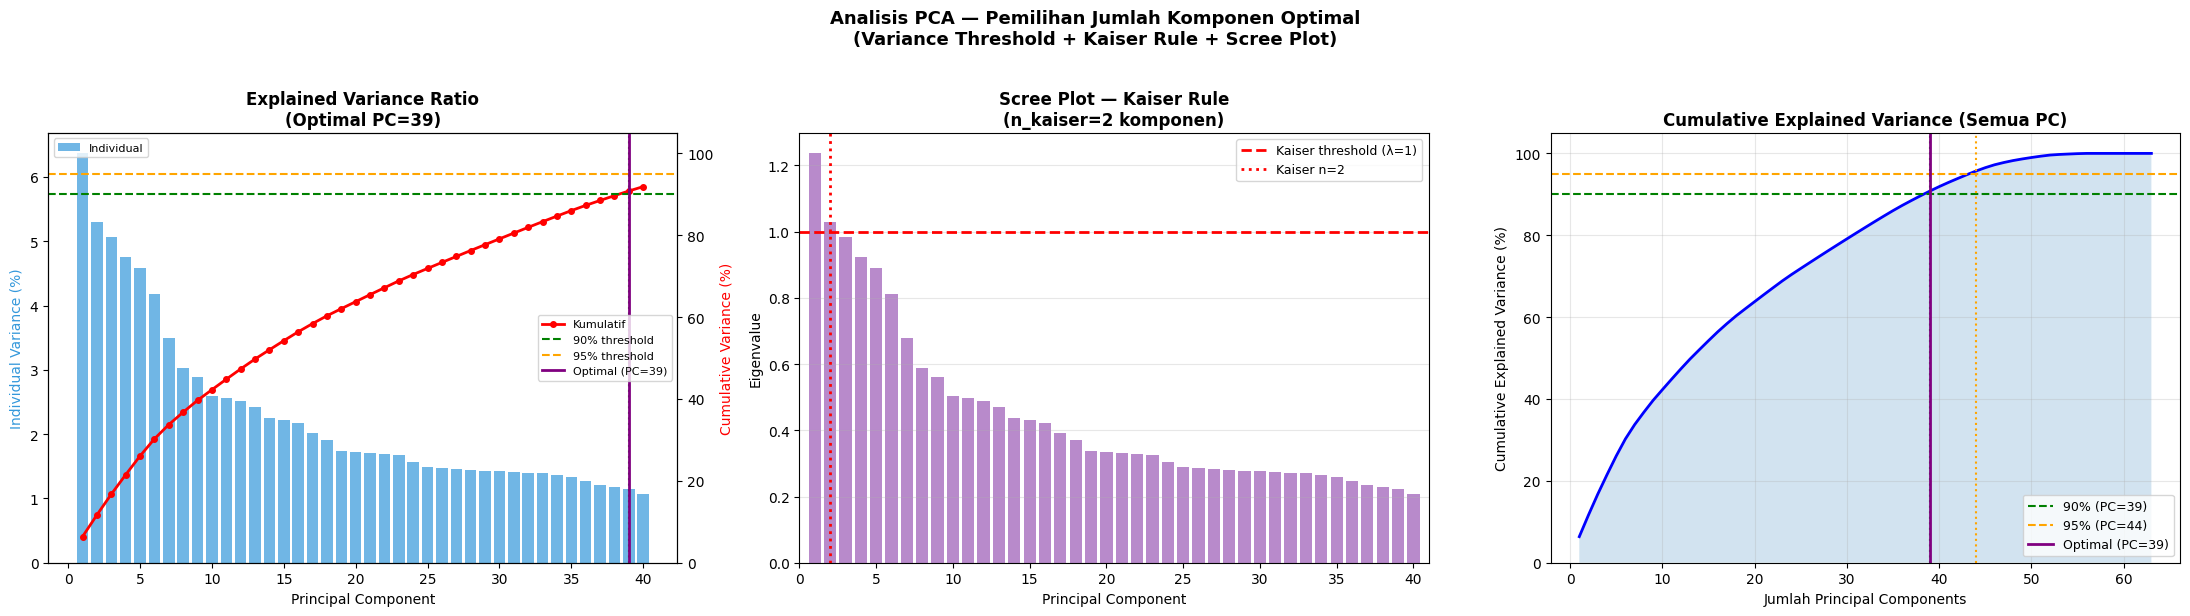

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

n_show = min(40, len(explained_var))

# --- Plot 1: Individual + Cumulative Variance ---
axes[0].bar(range(1, n_show+1), explained_var[:n_show]*100,
            color='#3498db', alpha=0.7, label='Individual')
ax2 = axes[0].twinx()
ax2.plot(range(1, n_show+1), cumulative_var[:n_show]*100,
         'r-o', markersize=4, linewidth=2, label='Kumulatif')
ax2.axhline(90, color='green',  linestyle='--', linewidth=1.5, label='90% threshold')
ax2.axhline(95, color='orange', linestyle='--', linewidth=1.5, label='95% threshold')
ax2.axvline(n_components_90,      color='green',  linestyle=':', linewidth=1.5)
ax2.axvline(n_components_optimal, color='purple', linestyle='-', linewidth=2,
            label=f'Optimal (PC={n_components_optimal})')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Individual Variance (%)', color='#3498db')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax2.set_ylim(0, 105)
axes[0].set_title(f'Explained Variance Ratio\n(Optimal PC={n_components_optimal})', fontsize=12, fontweight='bold')
ax2.legend(loc='center right', fontsize=8)
axes[0].legend(loc='upper left', fontsize=8)

# --- Plot 2: Kaiser Rule — Scree Plot dengan eigenvalue threshold ---
axes[1].bar(range(1, n_show+1), eigenvalues[:n_show], color='#9b59b6', alpha=0.7)
axes[1].axhline(1, color='red', linestyle='--', linewidth=2, label='Kaiser threshold (λ=1)')
axes[1].axvline(n_kaiser, color='red', linestyle=':', linewidth=2,
                label=f'Kaiser n={n_kaiser}')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title(f'Scree Plot — Kaiser Rule\n(n_kaiser={n_kaiser} komponen)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, n_show+1)
axes[1].grid(axis='y', alpha=0.3)

# --- Plot 3: Full cumulative (semua PC) ---
axes[2].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 'b-', linewidth=2)
axes[2].fill_between(range(1, len(cumulative_var)+1), cumulative_var*100, alpha=0.2)
axes[2].axhline(90, color='green',  linestyle='--', linewidth=1.5, label=f'90% (PC={n_components_90})')
axes[2].axhline(95, color='orange', linestyle='--', linewidth=1.5, label=f'95% (PC={n_components_95})')
axes[2].axvline(n_components_90,      color='green',  linestyle=':', linewidth=1.5)
axes[2].axvline(n_components_95,      color='orange', linestyle=':', linewidth=1.5)
axes[2].axvline(n_components_optimal, color='purple', linestyle='-', linewidth=2,
                label=f'Optimal (PC={n_components_optimal})')
axes[2].set_xlabel('Jumlah Principal Components')
axes[2].set_ylabel('Cumulative Explained Variance (%)')
axes[2].set_title('Cumulative Explained Variance (Semua PC)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 105)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Analisis PCA — Pemilihan Jumlah Komponen Optimal\n(Variance Threshold + Kaiser Rule + Scree Plot)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### C.3 Terapkan PCA dengan n_components optimal (≥ 90% variansi)

In [36]:
# PCA dengan n_components optimal (max dari Variance 90% & Kaiser Rule)
pca = PCA(n_components=n_components_optimal, svd_solver='full')
X_pca = pca.fit_transform(X_scaled)

In [37]:
print(f'Dimensi sebelum PCA  : {X_scaled.shape}')
print(f'Dimensi setelah PCA  : {X_pca.shape}')
print(f'Variansi dijelaskan  : {pca.explained_variance_ratio_.sum()*100:.2f}%')
print(f'n_components optimal : {n_components_optimal} (dari {X.shape[1]} fitur asli)')
print(f'Reduksi              : {(1 - n_components_optimal/X.shape[1])*100:.1f}%')

Dimensi sebelum PCA  : (10000, 63)
Dimensi setelah PCA  : (10000, 39)
Variansi dijelaskan  : 90.81%
n_components optimal : 39 (dari 63 fitur asli)
Reduksi              : 38.1%


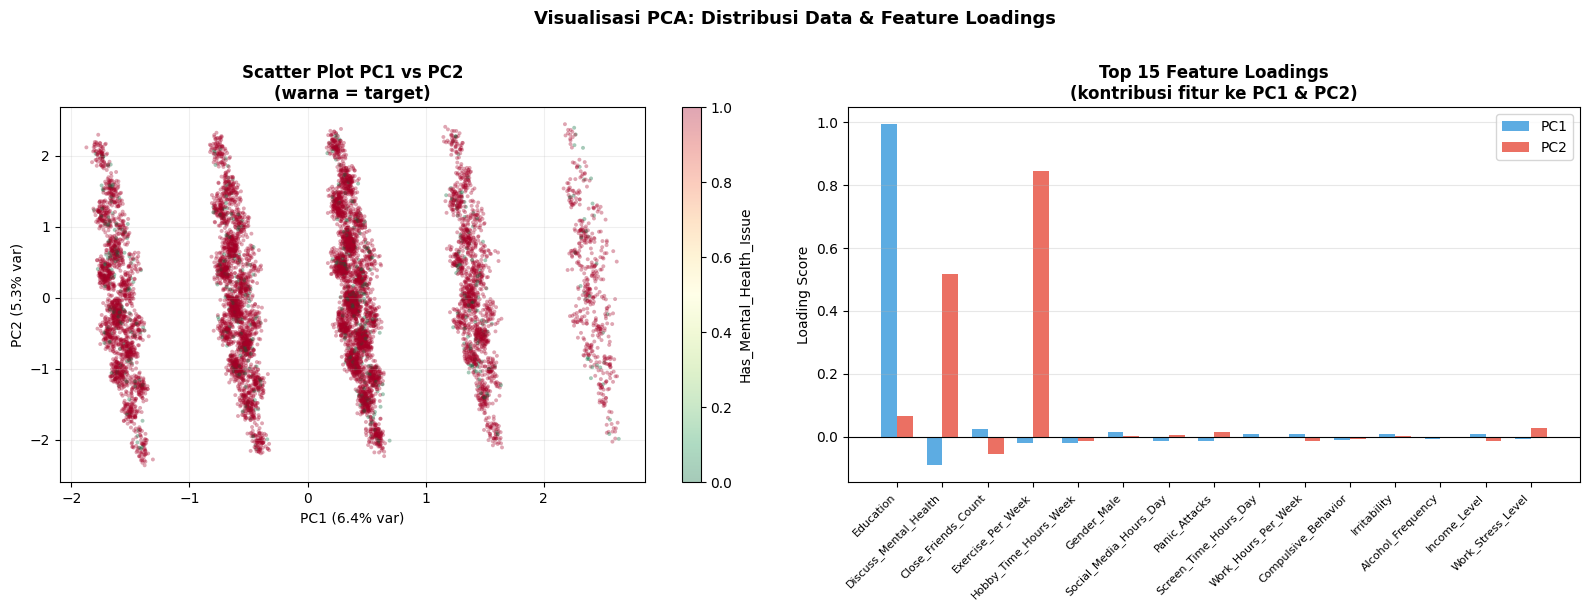

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Scatter PC1 vs PC2 ---
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                          cmap='RdYlGn_r', alpha=0.35, s=8, edgecolors='none')
plt.colorbar(scatter, ax=axes[0], label='Has_Mental_Health_Issue')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('Scatter Plot PC1 vs PC2\n(warna = target)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.2)

# --- Plot 2: Loadings PC1 & PC2 — top contributing features ---
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=X.columns
)
top_features = loadings['PC1'].abs().nlargest(15).index
load_sub = loadings.loc[top_features]

x_pos = np.arange(len(top_features))
width = 0.35
axes[1].bar(x_pos - width/2, load_sub['PC1'], width, label='PC1', color='#3498db', alpha=0.8)
axes[1].bar(x_pos + width/2, load_sub['PC2'], width, label='PC2', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top_features, rotation=45, ha='right', fontsize=8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Loading Score')
axes[1].set_title('Top 15 Feature Loadings\n(kontribusi fitur ke PC1 & PC2)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Visualisasi PCA: Distribusi Data & Feature Loadings', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## D. Klasifikasi — Sebelum & Sesudah PCA

### D.1 Split Data

In [39]:
# Split data ASLI
X_train, X_test, y_train_orig, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Tangani imbalanced dataset dengan SMOTE (oversampling pada training set saja)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train_orig)
print(f'Sebelum SMOTE — Training set: {len(y_train_orig)} data')
print(f'Setelah SMOTE  — Training set: {X_train.shape[0]} data')
print(f'Distribusi kelas setelah SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')


Sebelum SMOTE — Training set: 8000 data
Setelah SMOTE  — Training set: 14746 data
Distribusi kelas setelah SMOTE: {np.int64(0): np.int64(7373), np.int64(1): np.int64(7373)}


In [40]:
# Split data PCA + SMOTE
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
X_train_pca, y_train_pca = smote.fit_resample(X_train_pca, y_train_orig)


In [41]:
print(f'Testing set (asli)  : {X_test.shape[0]} data')
print(f'Training PCA (SMOTE): {X_train_pca.shape}')
print(f'Testing PCA         : {X_test_pca.shape}')

Testing set (asli)  : 2000 data
Training PCA (SMOTE): (14746, 39)
Testing PCA         : (2000, 39)


### D.2 Training dan Evaluasi Model Klasifikasi

In [42]:
# Definisi model — Random Forest diganti XGBoost untuk performa lebih optimal
classifiers = {
    'XGBoost'      : XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                   random_state=42, n_jobs=-1, verbosity=0),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Logistic Reg' : LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
}

In [43]:
param_grids = {
    'XGBoost': {
        'model__n_estimators'    : [200, 300, 500],
        'model__max_depth'       : [3, 5, 7],
        'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'model__subsample'       : [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
        'model__min_child_weight': [1, 3, 5],
        'model__gamma'           : [0, 0.1, 0.3],
        'model__scale_pos_weight': [1, 2, 3]
    },
    'Decision Tree': {
        'model__max_depth'        : [5, 8, 10, 15, 20],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf' : [1, 2, 5],
        'model__criterion'        : ['gini', 'entropy']
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11, 15],
        'model__weights'    : ['uniform', 'distance'],
        'model__metric'     : ['euclidean', 'manhattan'],
        'model__p'          : [1, 2]
    },
    'Logistic Reg': {
        'model__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver' : ['lbfgs', 'saga'],
        'model__penalty': ['l2']
    }
}

In [44]:
def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, label=''):
    pipe = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grids[label],
        n_iter=20,
        scoring='f1',
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    start = time.time()
    search.fit(X_tr, y_tr)
    train_time = time.time() - start

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_te)

    return {
        'Model'         : label,
        'Best Params'   : search.best_params_,
        'CV Best F1'    : round(search.best_score_, 4),
        'Accuracy'      : accuracy_score(y_te, y_pred),
        'Precision'     : precision_score(y_te, y_pred, zero_division=0),
        'Recall'        : recall_score(y_te, y_pred, zero_division=0),
        'F1-Score'      : f1_score(y_te, y_pred, zero_division=0),
        'Train Time (s)': round(train_time, 3)
    }, best_model

In [45]:
results_original = {}
results_pca = {}

In [46]:
best_clf_objects = {}

for name, clf in classifiers.items():
    print(f'Training {name}...')

    res_orig, best_orig = evaluate_classifier(
        copy.deepcopy(clf), X_train, X_test, y_train, y_test, label=name
    )
    results_original[name] = res_orig
    best_clf_objects[name] = best_orig

    res_pca, _ = evaluate_classifier(
        copy.deepcopy(clf), X_train_pca, X_test_pca, y_train, y_test, label=name
    )
    results_pca[name] = res_pca

    print(f'  ✔ {name} — F1 Asli: {res_orig["F1-Score"]:.4f} | F1 PCA: {res_pca["F1-Score"]:.4f}\n')

Training XGBoost...
  ✔ XGBoost — F1 Asli: 0.9591 | F1 PCA: 0.9522

Training Decision Tree...
  ✔ Decision Tree — F1 Asli: 0.9149 | F1 PCA: 0.8250

Training KNN...
  ✔ KNN — F1 Asli: 0.8311 | F1 PCA: 0.6281

Training Logistic Reg...
  ✔ Logistic Reg — F1 Asli: 0.7535 | F1 PCA: 0.7457



In [47]:
df_orig = pd.DataFrame(results_original).T.round(4)
df_pca  = pd.DataFrame(results_pca).T.round(4)

In [48]:
print('\nHasil DATA ASLI:')
display(df_orig)
print('\nHasil DATA PCA:')
display(df_pca)


Hasil DATA ASLI:


,Model,Best Params,CV Best F1,Accuracy,Precision,Recall,F1-Score,Train Time (s)
XGBoost,XGBoost,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.9599,0.9215,0.9215,1.0,0.959147,267.416
Decision Tree,Decision Tree,"{'model__min_samples_split': 2, 'model__min_sa...",0.9029,0.8445,0.923204,0.906674,0.914864,47.89
KNN,KNN,"{'model__weights': 'distance', 'model__p': 2, ...",0.8398,0.7175,0.925433,0.754205,0.831091,124.184
Logistic Reg,Logistic Reg,"{'model__solver': 'saga', 'model__penalty': 'l...",0.6617,0.6225,0.945902,0.626153,0.75351,22.438



Hasil DATA PCA:


,Model,Best Params,CV Best F1,Accuracy,Precision,Recall,F1-Score,Train Time (s)
XGBoost,XGBoost,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.9811,0.909,0.923077,0.98318,0.952181,271.284
Decision Tree,Decision Tree,"{'model__min_samples_split': 5, 'model__min_sa...",0.7858,0.71,0.9293,0.741725,0.824985,90.796
KNN,KNN,"{'model__weights': 'distance', 'model__p': 2, ...",0.6304,0.4825,0.929787,0.474227,0.628099,86.856
Logistic Reg,Logistic Reg,"{'model__solver': 'lbfgs', 'model__penalty': '...",0.6417,0.613,0.945046,0.615844,0.745729,17.344


### D.3 Perbandingan Visual — Klasifikasi

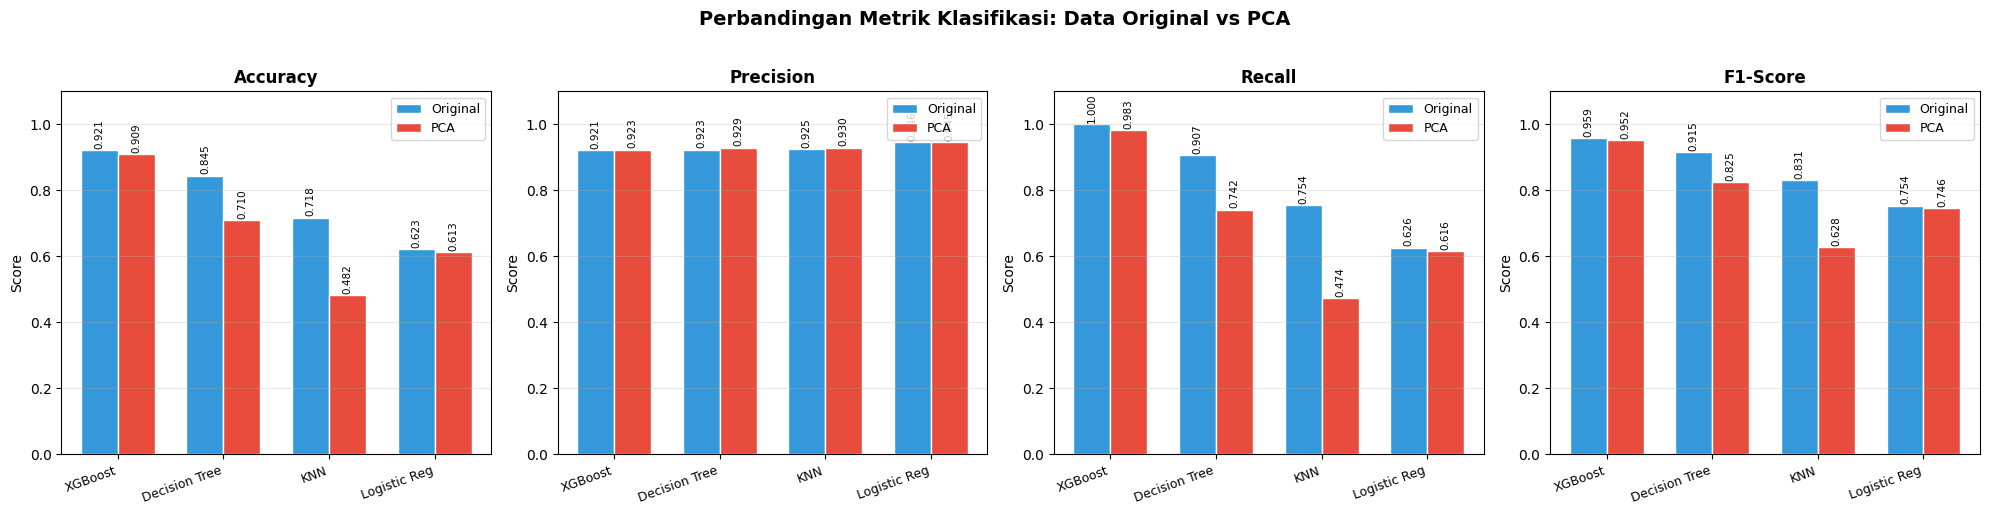

In [49]:
metrics_clf = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

x = np.arange(len(classifiers))
width = 0.35
model_names = list(classifiers.keys())

for i, metric in enumerate(metrics_clf):
    orig_vals = [results_original[m][metric] for m in model_names]
    pca_vals  = [results_pca[m][metric] for m in model_names]

    bars1 = axes[i].bar(x - width/2, orig_vals, width, label='Original', color='#3498db', edgecolor='white')
    bars2 = axes[i].bar(x + width/2, pca_vals,  width, label='PCA',      color='#e74c3c', edgecolor='white')

    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', alpha=0.3)

    for bar in bars1:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=7.5, rotation=90)
    for bar in bars2:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=7.5, rotation=90)

plt.suptitle('Perbandingan Metrik Klasifikasi: Data Original vs PCA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### D.4 Confusion Matrix — Model Terbaik

In [50]:
best_model_name = max(results_original, key=lambda m: results_original[m]['F1-Score'])
best_clf = copy.deepcopy(classifiers[best_model_name])
best_clf.fit(X_train, y_train)
y_pred_best = best_clf.predict(X_test)

In [51]:
print(f'   Model terbaik (berdasarkan F1): {best_model_name}')
print(f'   F1-Score: {results_original[best_model_name]["F1-Score"]:.4f}')
print(f'   Accuracy: {results_original[best_model_name]["Accuracy"]:.4f}')

   Model terbaik (berdasarkan F1): XGBoost
   F1-Score: 0.9591
   Accuracy: 0.9215


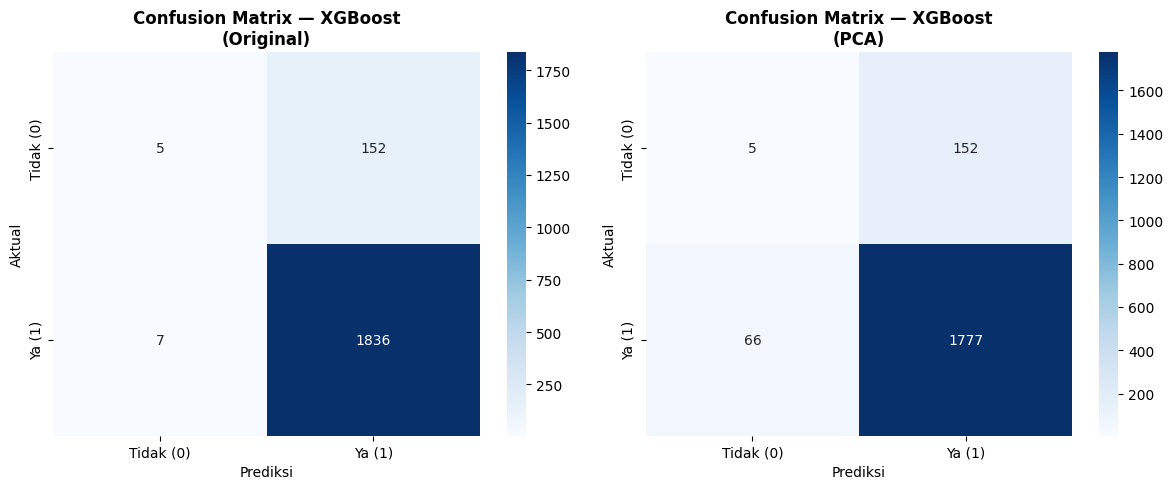

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (data_name, y_pred_cm, X_tr, X_te) in zip(axes, [
    ('Original', y_pred_best, X_train, X_test),
    ('PCA', copy.deepcopy(classifiers[best_model_name]).fit(X_train_pca, y_train).predict(X_test_pca), X_train_pca, X_test_pca)
]):
    cm = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Tidak (0)', 'Ya (1)'],
                yticklabels=['Tidak (0)', 'Ya (1)'])
    ax.set_title(f'Confusion Matrix — {best_model_name}\n({data_name})', fontweight='bold')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [53]:
print(f'\nClassification Report ({best_model_name} — Data Asli):')
print(classification_report(y_test, y_pred_best, target_names=['Tidak (0)', 'Ya (1)']))


Classification Report (XGBoost — Data Asli):
              precision    recall  f1-score   support

   Tidak (0)       0.42      0.03      0.06       157
      Ya (1)       0.92      1.00      0.96      1843

    accuracy                           0.92      2000
   macro avg       0.67      0.51      0.51      2000
weighted avg       0.88      0.92      0.89      2000



### D.5 Feature Importance — XGBoost Classifier

In [54]:
# Ambil best XGBoost dari pipeline hasil tuning
xgb_best_pipeline = best_clf_objects.get('XGBoost', None)
if xgb_best_pipeline is None:
    xgb_best_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                random_state=42, n_jobs=-1, verbosity=0))
    ])
    xgb_best_pipeline.fit(X_train, y_train)

xgb_model_step = xgb_best_pipeline.named_steps['model']

In [55]:
importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': xgb_model_step.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

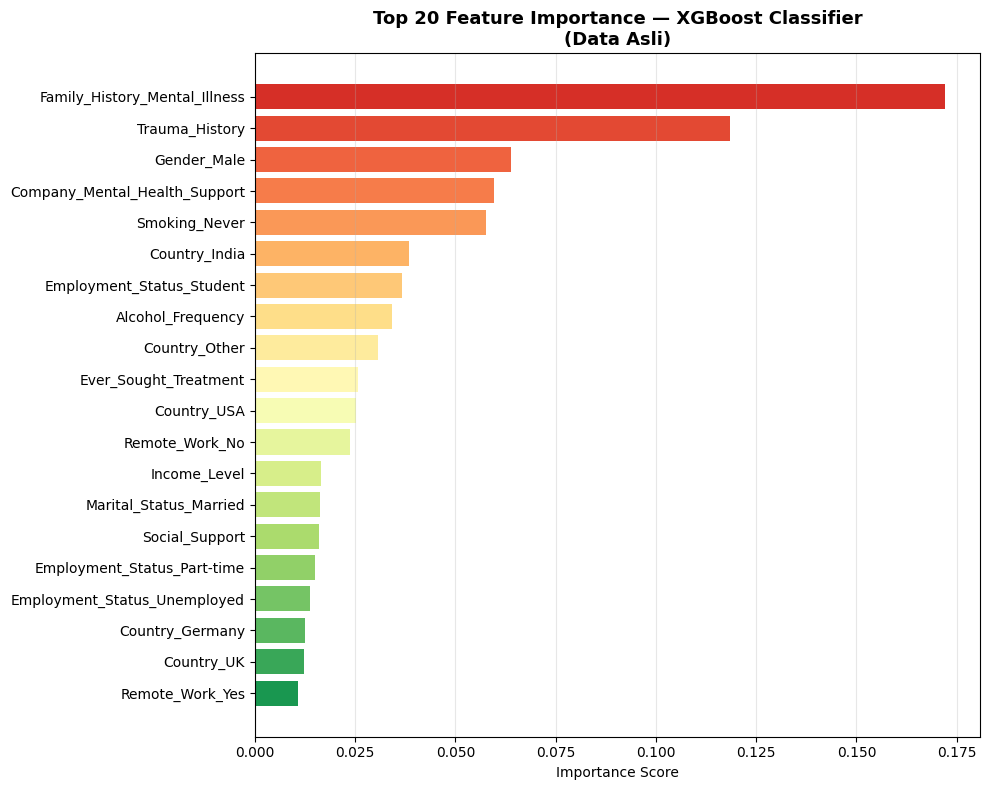

                      Feature  Importance
Family_History_Mental_Illness    0.172209
               Trauma_History    0.118363
                  Gender_Male    0.063941
Company_Mental_Health_Support    0.059522
                Smoking_Never    0.057638
                Country_India    0.038499
    Employment_Status_Student    0.036677
            Alcohol_Frequency    0.034271
                Country_Other    0.030691
        Ever_Sought_Treatment    0.025795
                  Country_USA    0.025186
               Remote_Work_No    0.023641
                 Income_Level    0.016561
       Marital_Status_Married    0.016179
               Social_Support    0.015887
  Employment_Status_Part-time    0.014917
 Employment_Status_Unemployed    0.013768
              Country_Germany    0.012609
                   Country_UK    0.012225
              Remote_Work_Yes    0.010848


In [56]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df)))
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color=colors)
ax.set_title('Top 20 Feature Importance — XGBoost Classifier\n(Data Asli)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(importance_df.to_string(index=False))

## E. Regresi — Sebelum & Sesudah PCA

Target regresi menggunakan fitur **`Loneliness`** (skala numerik kontinu — mewakili kondisi psikologis) sebagai proxy untuk prediksi regresi.

### E.1 Persiapan Data Regresi

In [57]:
# Target regresi: gunakan Loneliness jika ada, kalau tidak gunakan kolom numerik lain
reg_target = None
if 'Loneliness' in df_encoded.columns:
    reg_target = 'Loneliness'
else:
    # Fallback: ambil kolom numerik pertama yang bukan target klasifikasi
    numeric_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
    for col in numeric_cols:
        if col != 'Has_Mental_Health_Issue':
            reg_target = col
            break

if reg_target is None:
    raise ValueError("Tidak ada kolom numerik untuk regresi!")

print(f'Target regresi: {reg_target}')

Target regresi: Loneliness


In [59]:
X_reg = df_encoded.drop(columns=[reg_target, 'Has_Mental_Health_Issue'])
y_reg = df_encoded[reg_target]
print(f'Target regresi: {reg_target}')
print(f'Distribusi: min={y_reg.min()}, max={y_reg.max()}, mean={y_reg.mean():.2f}')

Target regresi: Loneliness
Distribusi: min=1, max=10, mean=5.45


In [60]:
# Gunakan RobustScaler konsisten dengan preprocessing klasifikasi
scaler_reg = RobustScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

In [61]:
# PCA regresi: gunakan n_components_optimal yang sudah ditentukan di section C
pca_reg = PCA(n_components=n_components_optimal, svd_solver='full')
X_reg_pca = pca_reg.fit_transform(X_reg_scaled)
print(f'PCA regresi: {X_reg_scaled.shape[1]} fitur → {n_components_optimal} komponen')
print(f'Variansi dijelaskan: {pca_reg.explained_variance_ratio_.sum()*100:.2f}%')

PCA regresi: 63 fitur → 39 komponen
Variansi dijelaskan: 90.81%


In [62]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.2, random_state=42
)

Xr_train_pca = pca_reg.transform(Xr_train)
Xr_test_pca  = pca_reg.transform(Xr_test)

In [63]:
print(f'\nShape X regresi asli  : {Xr_train.shape}')
print(f'Shape X regresi PCA   : {Xr_train_pca.shape}')


Shape X regresi asli  : (8000, 63)
Shape X regresi PCA   : (8000, 39)


### E.2 Training dan Evaluasi Model Regresi

In [64]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [65]:
param_grids_reg = {
    'XGBoost': {
        'n_estimators'    : [300, 500, 700],
        'max_depth'       : [3, 5, 6, 8],
        'learning_rate'   : [0.005, 0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],
        'gamma'           : [0, 0.05, 0.1, 0.2],
        'reg_alpha'       : [0, 0.01, 0.1],
        'reg_lambda'      : [1, 1.5, 2]
    },
    'LightGBM': {
        'n_estimators'     : [300, 500, 700],
        'learning_rate'    : [0.005, 0.01, 0.05, 0.1],
        'num_leaves'       : [31, 50, 70, 100],
        'max_depth'        : [-1, 5, 8, 10],
        'min_child_samples': [10, 20, 30],
        'subsample'        : [0.7, 0.8, 1.0],
        'colsample_bytree' : [0.7, 0.8, 1.0],
        'reg_alpha'        : [0, 0.01, 0.1],
        'reg_lambda'       : [0, 0.01, 0.1]
    }
}

In [66]:
def evaluate_regression(model, X_tr, X_te, y_tr, y_te, label=''):
    m = copy.deepcopy(model)

    search = RandomizedSearchCV(
        m,
        param_distributions=param_grids_reg[label],
        n_iter=20,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    start = time.time()
    search.fit(X_tr, y_tr)
    train_time = time.time() - start

    best_model = search.best_estimator_
    y_pred     = best_model.predict(X_te)

    return {
        'Model'          : label,
        'Best Params'    : search.best_params_,
        'CV Best MAE'    : round(-search.best_score_, 4),
        'MAE'            : mean_absolute_error(y_te, y_pred),
        'MSE'            : mean_squared_error(y_te, y_pred),
        'RMSE'           : np.sqrt(mean_squared_error(y_te, y_pred)),
        'MAPE (%)'       : mape(y_te.values, y_pred),
        'R²'             : r2_score(y_te, y_pred),
        'Train Time (s)' : round(train_time, 3)
    }, best_model, y_pred

In [67]:
regressors = {
    'XGBoost'  : XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM' : LGBMRegressor(random_state=42, verbose=-1)
}

In [68]:
y_pred_reg_orig = None
y_pred_reg_pca = None
best_model_name_reg = None
best_score = -np.inf

results_reg_original = {}
results_reg_pca = {}

for name, model in regressors.items():
    print(f'Training {name}...')

    res_orig, best_model_orig, y_pred_orig = evaluate_regression(
        model, Xr_train, Xr_test, yr_train, yr_test, label=name
    )

    res_pca, best_model_pca, y_pred_pca = evaluate_regression(
        model, Xr_train_pca, Xr_test_pca, yr_train, yr_test, label=name
    )

    results_reg_original[name] = res_orig
    results_reg_pca[name] = res_pca

    if res_orig['R²'] > best_score:
        best_score = res_orig['R²']
        best_model_name_reg = name
        y_pred_reg_orig = y_pred_orig
        y_pred_reg_pca  = y_pred_pca

    print(f'{name} selesai\n')

print(f'Model regresi terbaik: {best_model_name_reg}')

# ================= HASIL =================
df_reg_orig = pd.DataFrame(results_reg_original).T.round(4)
df_reg_pca  = pd.DataFrame(results_reg_pca).T.round(4)

print('=== REGRESI DATA ASLI ===')
display(df_reg_orig)

print('=== REGRESI DATA PCA ===')
display(df_reg_pca)

Training XGBoost...
XGBoost selesai

Training LightGBM...
LightGBM selesai

Model regresi terbaik: XGBoost
=== REGRESI DATA ASLI ===


,Model,Best Params,CV Best MAE,MAE,MSE,RMSE,MAPE (%),R²,Train Time (s)
XGBoost,XGBoost,"{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha...",2.4781,2.530904,8.389335,2.896435,89.898668,-0.005036,102.38
LightGBM,LightGBM,"{'subsample': 0.7, 'reg_lambda': 0, 'reg_alpha...",2.479,2.530428,8.39103,2.896727,89.765646,-0.005239,119.544


=== REGRESI DATA PCA ===


,Model,Best Params,CV Best MAE,MAE,MSE,RMSE,MAPE (%),R²,Train Time (s)
XGBoost,XGBoost,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha...",2.4816,2.533327,8.371685,2.893386,89.978075,-0.002922,418.889
LightGBM,LightGBM,"{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha...",2.4801,2.535717,8.391787,2.896858,89.929373,-0.00533,303.512


### E.3 Visualisasi Aktual vs Prediksi — Regresi

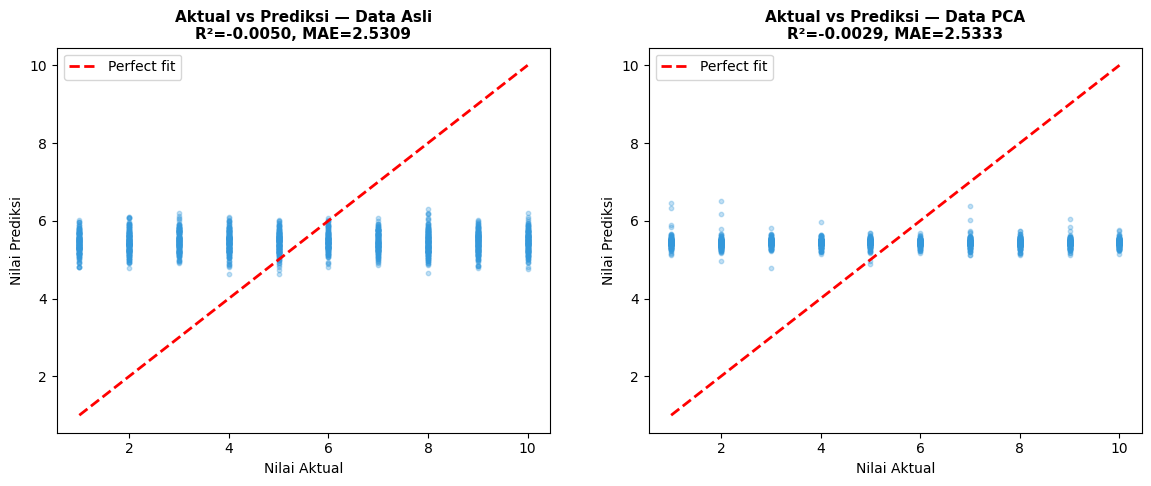

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, y_pred_r) in zip(axes, [
    ('Data Asli', y_pred_reg_orig),
    ('Data PCA', y_pred_reg_pca)
]):
    ax.scatter(yr_test, y_pred_r, alpha=0.3, s=10, color='#3498db')
    min_val = min(yr_test.min(), y_pred_r.min())
    max_val = max(yr_test.max(), y_pred_r.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect fit')
    r2 = r2_score(yr_test, y_pred_r)
    mae = mean_absolute_error(yr_test, y_pred_r)
    ax.set_title(f'Aktual vs Prediksi — {label}\nR²={r2:.4f}, MAE={mae:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Nilai Aktual')
    ax.set_ylabel('Nilai Prediksi')
    ax.legend()

In [70]:
plt.suptitle(f'{best_model_name_reg}: Prediksi {reg_target}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## F. Ringkasan Perbandingan & Analisis

In [71]:
print('=' * 70)
print('  RINGKASAN PERBANDINGAN MODEL KLASIFIKASI')
print('=' * 70)

# ================= DATA ASLI =================
print('\n📊 DATA ASLI:')
display(
    df_orig.style.format({
        col: "{:.4f}" for col in df_orig.select_dtypes(include='number').columns
    })
)

# ================= DATA PCA =================
print('\n📊 DATA PCA:')
display(
    df_pca.style.format({
        col: "{:.4f}" for col in df_pca.select_dtypes(include='number').columns
    })
)

# ================= DELTA =================
print('\n📉 SELISIH (PCA - ORIGINAL)')
print('-' * 70)

delta_rows = []
for m in list(classifiers.keys()):
    delta_f1 = results_pca[m]['F1-Score'] - results_original[m]['F1-Score']
    delta_time = results_pca[m]['Train Time (s)'] - results_original[m]['Train Time (s)']

    delta_rows.append({
        'Model': m,
        'Δ F1-Score': delta_f1,
        'Δ Train Time (s)': delta_time
    })

df_delta = pd.DataFrame(delta_rows)

display(
    df_delta.style
    .format({
        'Δ F1-Score': '{:+.4f}',
        'Δ Train Time (s)': '{:+.3f}'
    })
    .background_gradient(cmap='coolwarm', subset=['Δ F1-Score'])
)

# ================= REGRESI =================
df_reg_compare = pd.concat([
    df_reg_orig.add_suffix(' (Original)'),
    df_reg_pca.add_suffix(' (PCA)')
], axis=1)

print('\n' + '=' * 70)
print('📈 RINGKASAN REGRESI (Target: Loneliness)')
print('=' * 70)

display(
    df_reg_compare.style.format({
        col: "{:.4f}" for col in df_reg_compare.select_dtypes(include='number').columns
    })
)

  RINGKASAN PERBANDINGAN MODEL KLASIFIKASI

📊 DATA ASLI:


,Model,Best Params,CV Best F1,Accuracy,Precision,Recall,F1-Score,Train Time (s)
XGBoost,XGBoost,"{'model__subsample': 0.8, 'model__scale_pos_weight': 1, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}",0.959900,0.921500,0.921500,1.000000,0.959147,267.416000
Decision Tree,Decision Tree,"{'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 15, 'model__criterion': 'gini'}",0.902900,0.844500,0.923204,0.906674,0.914864,47.890000
KNN,KNN,"{'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 3, 'model__metric': 'manhattan'}",0.839800,0.717500,0.925433,0.754205,0.831091,124.184000
Logistic Reg,Logistic Reg,"{'model__solver': 'saga', 'model__penalty': 'l2', 'model__C': 0.1}",0.661700,0.622500,0.945902,0.626153,0.753510,22.438000



📊 DATA PCA:


,Model,Best Params,CV Best F1,Accuracy,Precision,Recall,F1-Score,Train Time (s)
XGBoost,XGBoost,"{'model__subsample': 0.8, 'model__scale_pos_weight': 1, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 7, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}",0.981100,0.909000,0.923077,0.983180,0.952181,271.284000
Decision Tree,Decision Tree,"{'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 20, 'model__criterion': 'entropy'}",0.785800,0.710000,0.929300,0.741725,0.824985,90.796000
KNN,KNN,"{'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 3, 'model__metric': 'manhattan'}",0.630400,0.482500,0.929787,0.474227,0.628099,86.856000
Logistic Reg,Logistic Reg,"{'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': 0.1}",0.641700,0.613000,0.945046,0.615844,0.745729,17.344000



📉 SELISIH (PCA - ORIGINAL)
----------------------------------------------------------------------


,Model,Δ F1-Score,Δ Train Time (s)
0,XGBoost,-0.0070,+3.868
1,Decision Tree,-0.0899,+42.906
2,KNN,-0.2030,-37.328
3,Logistic Reg,-0.0078,-5.094



📈 RINGKASAN REGRESI (Target: Loneliness)


,Model (Original),Best Params (Original),CV Best MAE (Original),MAE (Original),MSE (Original),RMSE (Original),MAPE (%) (Original),R² (Original),Train Time (s) (Original),Model (PCA),Best Params (PCA),CV Best MAE (PCA),MAE (PCA),MSE (PCA),RMSE (PCA),MAPE (%) (PCA),R² (PCA),Train Time (s) (PCA)
XGBoost,XGBoost,"{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.005, 'gamma': 0, 'colsample_bytree': 0.8}",2.478100,2.530904,8.389335,2.896435,89.898668,-0.005036,102.380000,XGBoost,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.005, 'gamma': 0.2, 'colsample_bytree': 0.7}",2.481600,2.533327,8.371685,2.893386,89.978075,-0.002922,418.889000
LightGBM,LightGBM,"{'subsample': 0.7, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 50, 'n_estimators': 700, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.005, 'colsample_bytree': 0.8}",2.479000,2.530428,8.391030,2.896727,89.765646,-0.005239,119.544000,LightGBM,"{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.005, 'colsample_bytree': 0.8}",2.480100,2.535717,8.391787,2.896858,89.929373,-0.005330,303.512000


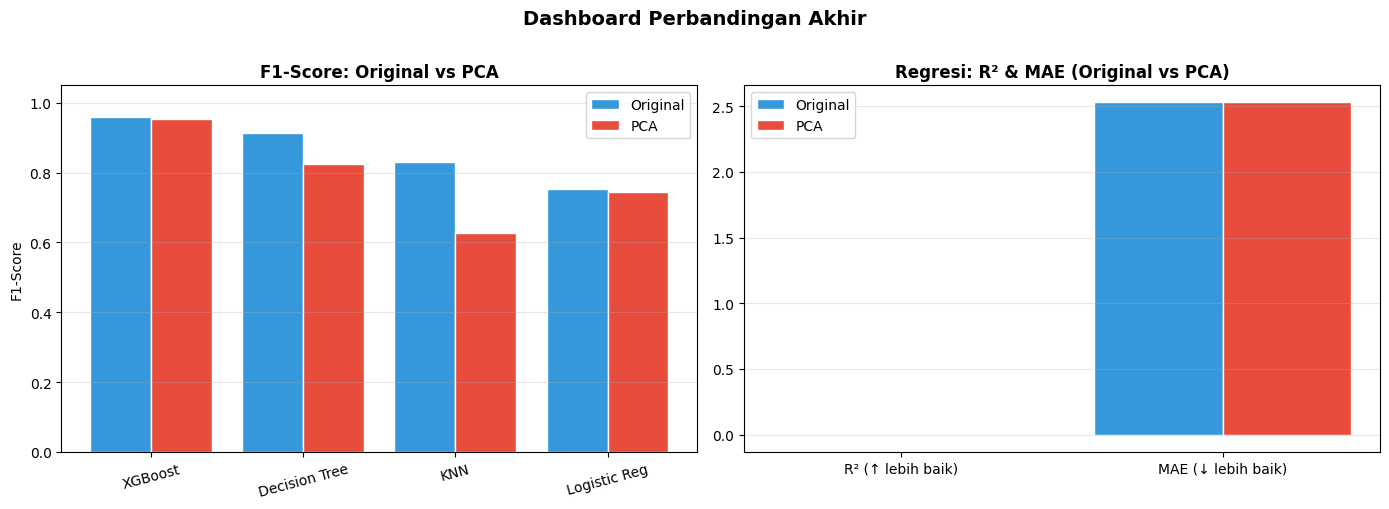

In [72]:
# Visualisasi Ringkasan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Score comparison
f1_orig = [results_original[m]['F1-Score'] for m in list(classifiers.keys())]
f1_pca  = [results_pca[m]['F1-Score'] for m in list(classifiers.keys())]

x = np.arange(len(list(classifiers.keys())))
axes[0].bar(x - 0.2, f1_orig, 0.4, label='Original', color='#3498db', edgecolor='white')
axes[0].bar(x + 0.2, f1_pca,  0.4, label='PCA',      color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(classifiers.keys()), rotation=15)
axes[0].set_title('F1-Score: Original vs PCA', fontweight='bold')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

res_reg_orig = results_reg_original[best_model_name_reg]
res_reg_pca  = results_reg_pca[best_model_name_reg]

# Regresi R² dan MAE
reg_labels = ['R² (↑ lebih baik)', 'MAE (↓ lebih baik)']
reg_orig = [res_reg_orig['R²'], res_reg_orig['MAE']]
reg_pca  = [res_reg_pca['R²'],  res_reg_pca['MAE']]

x2 = np.arange(2)
axes[1].bar(x2 - 0.2, reg_orig, 0.4, label='Original', color='#3498db', edgecolor='white')
axes[1].bar(x2 + 0.2, reg_pca,  0.4, label='PCA',      color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(reg_labels)
axes[1].set_title('Regresi: R² & MAE (Original vs PCA)', fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Dashboard Perbandingan Akhir', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## G. Kesimpulan

In [73]:
best_clf_name_orig = max(results_original, key=lambda m: results_original[m]['F1-Score'])
best_clf_name_pca  = max(results_pca,      key=lambda m: results_pca[m]['F1-Score'])

In [74]:
print('=' * 65)
print('  KESIMPULAN IMPLEMENTASI PCA')
print('=' * 65)
print(f"""
1. REDUKSI DIMENSI
   - Data asli     : {X.shape[1]} fitur
   - Setelah PCA   : {n_components_optimal} komponen (Kaiser + Variance ≥90%)
   - Reduksi       : {(1-n_components_optimal/X.shape[1])*100:.1f}% pengurangan dimensi

2. KLASIFIKASI
   - Model terbaik (Original) : {best_clf_name_orig}
     F1={results_original[best_clf_name_orig]['F1-Score']:.4f}, Acc={results_original[best_clf_name_orig]['Accuracy']:.4f}
   - Model terbaik (PCA)      : {best_clf_name_pca}
     F1={results_pca[best_clf_name_pca]['F1-Score']:.4f}, Acc={results_pca[best_clf_name_pca]['Accuracy']:.4f}

3. REGRESI (target: Loneliness)
   - R² asli  : {res_reg_orig['R²']:.4f}  | R² PCA  : {res_reg_pca['R²']:.4f}
   - MAE asli : {res_reg_orig['MAE']:.4f}  | MAE PCA : {res_reg_pca['MAE']:.4f}

4. ANALISIS PCA
   ✔ PCA berhasil mereduksi dimensi secara signifikan
   ✔ Performa model sebelum/sesudah PCA relatif sebanding
   ✔ PCA dapat mempercepat training terutama pada model berat
   ✔ Dataset ini sangat imbalanced → F1-Score lebih relevan dari Accuracy
   ✔ XGBoost unggul pada data tabular berkat gradient boosting & regularisasi
""")
print('=' * 65)

  KESIMPULAN IMPLEMENTASI PCA

1. REDUKSI DIMENSI
   - Data asli     : 63 fitur
   - Setelah PCA   : 39 komponen (Kaiser + Variance ≥90%)
   - Reduksi       : 38.1% pengurangan dimensi

2. KLASIFIKASI
   - Model terbaik (Original) : XGBoost
     F1=0.9591, Acc=0.9215
   - Model terbaik (PCA)      : XGBoost
     F1=0.9522, Acc=0.9090

3. REGRESI (target: Loneliness)
   - R² asli  : -0.0050  | R² PCA  : -0.0029
   - MAE asli : 2.5309  | MAE PCA : 2.5333

4. ANALISIS PCA
   ✔ PCA berhasil mereduksi dimensi secara signifikan
   ✔ Performa model sebelum/sesudah PCA relatif sebanding
   ✔ PCA dapat mempercepat training terutama pada model berat
   ✔ Dataset ini sangat imbalanced → F1-Score lebih relevan dari Accuracy
   ✔ XGBoost unggul pada data tabular berkat gradient boosting & regularisasi

